In [1]:
import time
notebook_start = time.perf_counter()

import os, json, pandas as pd, numpy as np, matplotlib.pyplot as plt, shap, joblib, thermoift.PLOT_SETTINGS as ps
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator, LogLocator
from sklearn.model_selection import train_test_split, cross_validate, KFold
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from thermoift.rng_utils import get_rng
from thermoift import MLPostprocessing, plot_correlation_heatmap, print_model_metrics

# Respect SLURM CPU allocation — prevents all 254 node CPUs being grabbed
n_cpus = int(os.environ.get("SLURM_CPUS_PER_TASK", 4))
os.environ["OMP_NUM_THREADS"]      = str(n_cpus)
os.environ["MKL_NUM_THREADS"]      = str(n_cpus)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cpus)
os.environ["NUMEXPR_NUM_THREADS"]  = str(n_cpus)
print(f"Thread limit set to {n_cpus} (SLURM_CPUS_PER_TASK)")

Thread limit set to 4 (SLURM_CPUS_PER_TASK)


In [2]:
OUTPUT_FOLDER = "XGBoost_THICKNESS_OUTPUTS"
SEED          = 655552
TEST_ROWS     = None


In [3]:
df = pd.read_csv("../interfacial_results_dataset_A4.csv")

if isinstance(TEST_ROWS, str) and TEST_ROWS.strip().lower() in ("", "none", "null"):
    TEST_ROWS = None
if TEST_ROWS is not None:
    TEST_ROWS = int(TEST_ROWS)
    df = df.iloc[:TEST_ROWS].copy()
    print(f"Test mode: using first {TEST_ROWS} rows only")

print(f"Total samples: {len(df)}")
print(f"\ninterfacial_thickness statistics:")
print(df["interfacial_thickness"].describe())

Total samples: 19361

interfacial_thickness statistics:
count    19361.000000
mean         1.353666
std          0.682266
min          0.682573
25%          0.887208
50%          1.109909
75%          1.574425
max          5.659519
Name: interfacial_thickness, dtype: float64


In [4]:
target     = "interfacial_thickness"
rng        = get_rng(seed=SEED)

z_columns  = [col for col in df.columns if col.startswith("z_")]
Z_non_zero = [col for col in z_columns if (df[col] != 0).any()]
features   = ["temperature", "pressure"] + Z_non_zero

print(f"Selected features: {features}")

X = df[features]
y = df[target]

# 70/15/15 split: first 70/30, then split 30 into 15/15
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=SEED)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED)

print(f"\nTraining samples:   {X_train.shape[0]}")
print(f"Testing samples:    {X_test.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")

Selected features: ['temperature', 'pressure', 'z_carbon dioxide', 'z_hydrogen', 'z_nitrogen', 'z_argon', 'z_methane', 'z_oxygen', 'z_carbon monoxide', 'z_hydrogen sulfide']

Training samples:   13552
Testing samples:    2904
Validation samples: 2905


In [5]:
# XGBoost Regressor
xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=rng,
    n_jobs=n_cpus)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

y_train_pred = xgb_model.predict(X_train)
y_test_pred  = xgb_model.predict(X_test)
y_val_pred   = xgb_model.predict(X_val)

# Metrics
metrics = print_model_metrics(y_train, y_train_pred, y_test, y_test_pred, target, unit="nm", y_val=y_val, y_val_pred=y_val_pred)

Model Performance for interfacial_thickness

Training Set:
  R²:   0.999800
  RMSE: 0.009659 nm
  MAE:  0.005949 nm

Test Set:
  R²:   0.999477
  RMSE: 0.015762 nm
  MAE:  0.007852 nm

Validation Set:
  R²:   0.999545
  RMSE: 0.014360 nm
  MAE:  0.007571 nm


In [6]:
results_df = pd.DataFrame({
    "idx": np.concatenate([y_train.index, y_test.index, y_val.index]),
    "actual": np.concatenate([y_train.values, y_test.values, y_val.values]),
    "predicted": np.concatenate([y_train_pred, y_test_pred, y_val_pred]),
    "split": ["train"]*len(y_train) + ["test"]*len(y_test) + ["val"]*len(y_val),
})
os.makedirs(OUTPUT_FOLDER, exist_ok=True)
results_df.to_csv(os.path.join(OUTPUT_FOLDER, f"XGBoost_{target}_predictions.csv"), index=False)
print(f"Predictions saved: {len(results_df)} rows")

# Save fitted model for future use without retraining
model_path = os.path.join(OUTPUT_FOLDER, f"XGBoost_{target}_model.joblib")
joblib.dump(xgb_model, model_path)
print(f"Model saved to: {model_path}")

Predictions saved: 19361 rows
Model saved to: XGBoost_THICKNESS_OUTPUTS/XGBoost_interfacial_thickness_model.joblib


In [7]:
# 5-fold cross-validation — single pass, all 4 metrics (5 fits instead of 20)
# n_jobs=1: XGBRegressor already parallelizes internally; loky workers fight over /dev/shm
cv_results = cross_validate(
    xgb_model, X, y, cv=5,
    scoring={
        "r2":   "r2",
        "rmse": "neg_root_mean_squared_error",
        "mae":  "neg_mean_absolute_error",
        "mape": "neg_mean_absolute_percentage_error",
    },
    n_jobs=1,
)
cv_r2_scores   = cv_results["test_r2"]
cv_rmse_scores = -cv_results["test_rmse"]
cv_mae_scores  = -cv_results["test_mae"]
cv_mape_scores = -cv_results["test_mape"]

print(f"Cross-Validation R² Scores:   {cv_r2_scores}")
print(f"Mean CV R²:   {cv_r2_scores.mean():.6f} (+/- {cv_r2_scores.std() * 2:.6f})")
print(f"\nCross-Validation RMSE Scores: {cv_rmse_scores}")
print(f"Mean CV RMSE: {cv_rmse_scores.mean():.6f} (+/- {cv_rmse_scores.std() * 2:.6f})")
print(f"\nCross-Validation MAE Scores:  {cv_mae_scores}")
print(f"Mean CV MAE:  {cv_mae_scores.mean():.6f} (+/- {cv_mae_scores.std() * 2:.6f})")
print(f"\nCross-Validation MAPE Scores: {cv_mape_scores * 100}")
print(f"Mean CV MAPE: {cv_mape_scores.mean() * 100:.4f}% (+/- {cv_mape_scores.std() * 2 * 100:.4f}%)")

Cross-Validation R² Scores:   [0.99926091 0.99900091 0.98691541 0.99841247 0.99885745]
Mean CV R²:   0.996489 (+/- 0.009590)

Cross-Validation RMSE Scores: [0.01725531 0.02108083 0.07940913 0.0283034  0.0236933 ]
Mean CV RMSE: 0.033948 (+/- 0.046026)

Cross-Validation MAE Scores:  [0.00907884 0.01237786 0.01313712 0.01295343 0.01125672]
Mean CV MAE:  0.011761 (+/- 0.002986)

Cross-Validation MAPE Scores: [0.6744041  0.91785159 0.71884136 0.91089118 0.73831064]
Mean CV MAPE: 0.7921% (+/- 0.2040%)


n_estimators sweep complete.
  n_est=   50 | Train RMSE=0.0678  CV RMSE=0.0711  Test RMSE=0.0705
  n_est=  100 | Train RMSE=0.0172  CV RMSE=0.0216  Test RMSE=0.0207
  n_est=  200 | Train RMSE=0.0119  CV RMSE=0.0169  Test RMSE=0.0163
  n_est=  300 | Train RMSE=0.0106  CV RMSE=0.0161  Test RMSE=0.0157
  n_est=  500 | Train RMSE=0.0093  CV RMSE=0.0156  Test RMSE=0.0154
  n_est=  750 | Train RMSE=0.0085  CV RMSE=0.0153  Test RMSE=0.0151
  n_est= 1000 | Train RMSE=0.0080  CV RMSE=0.0151  Test RMSE=0.0150
  n_est= 1500 | Train RMSE=0.0076  CV RMSE=0.0149  Test RMSE=0.0149


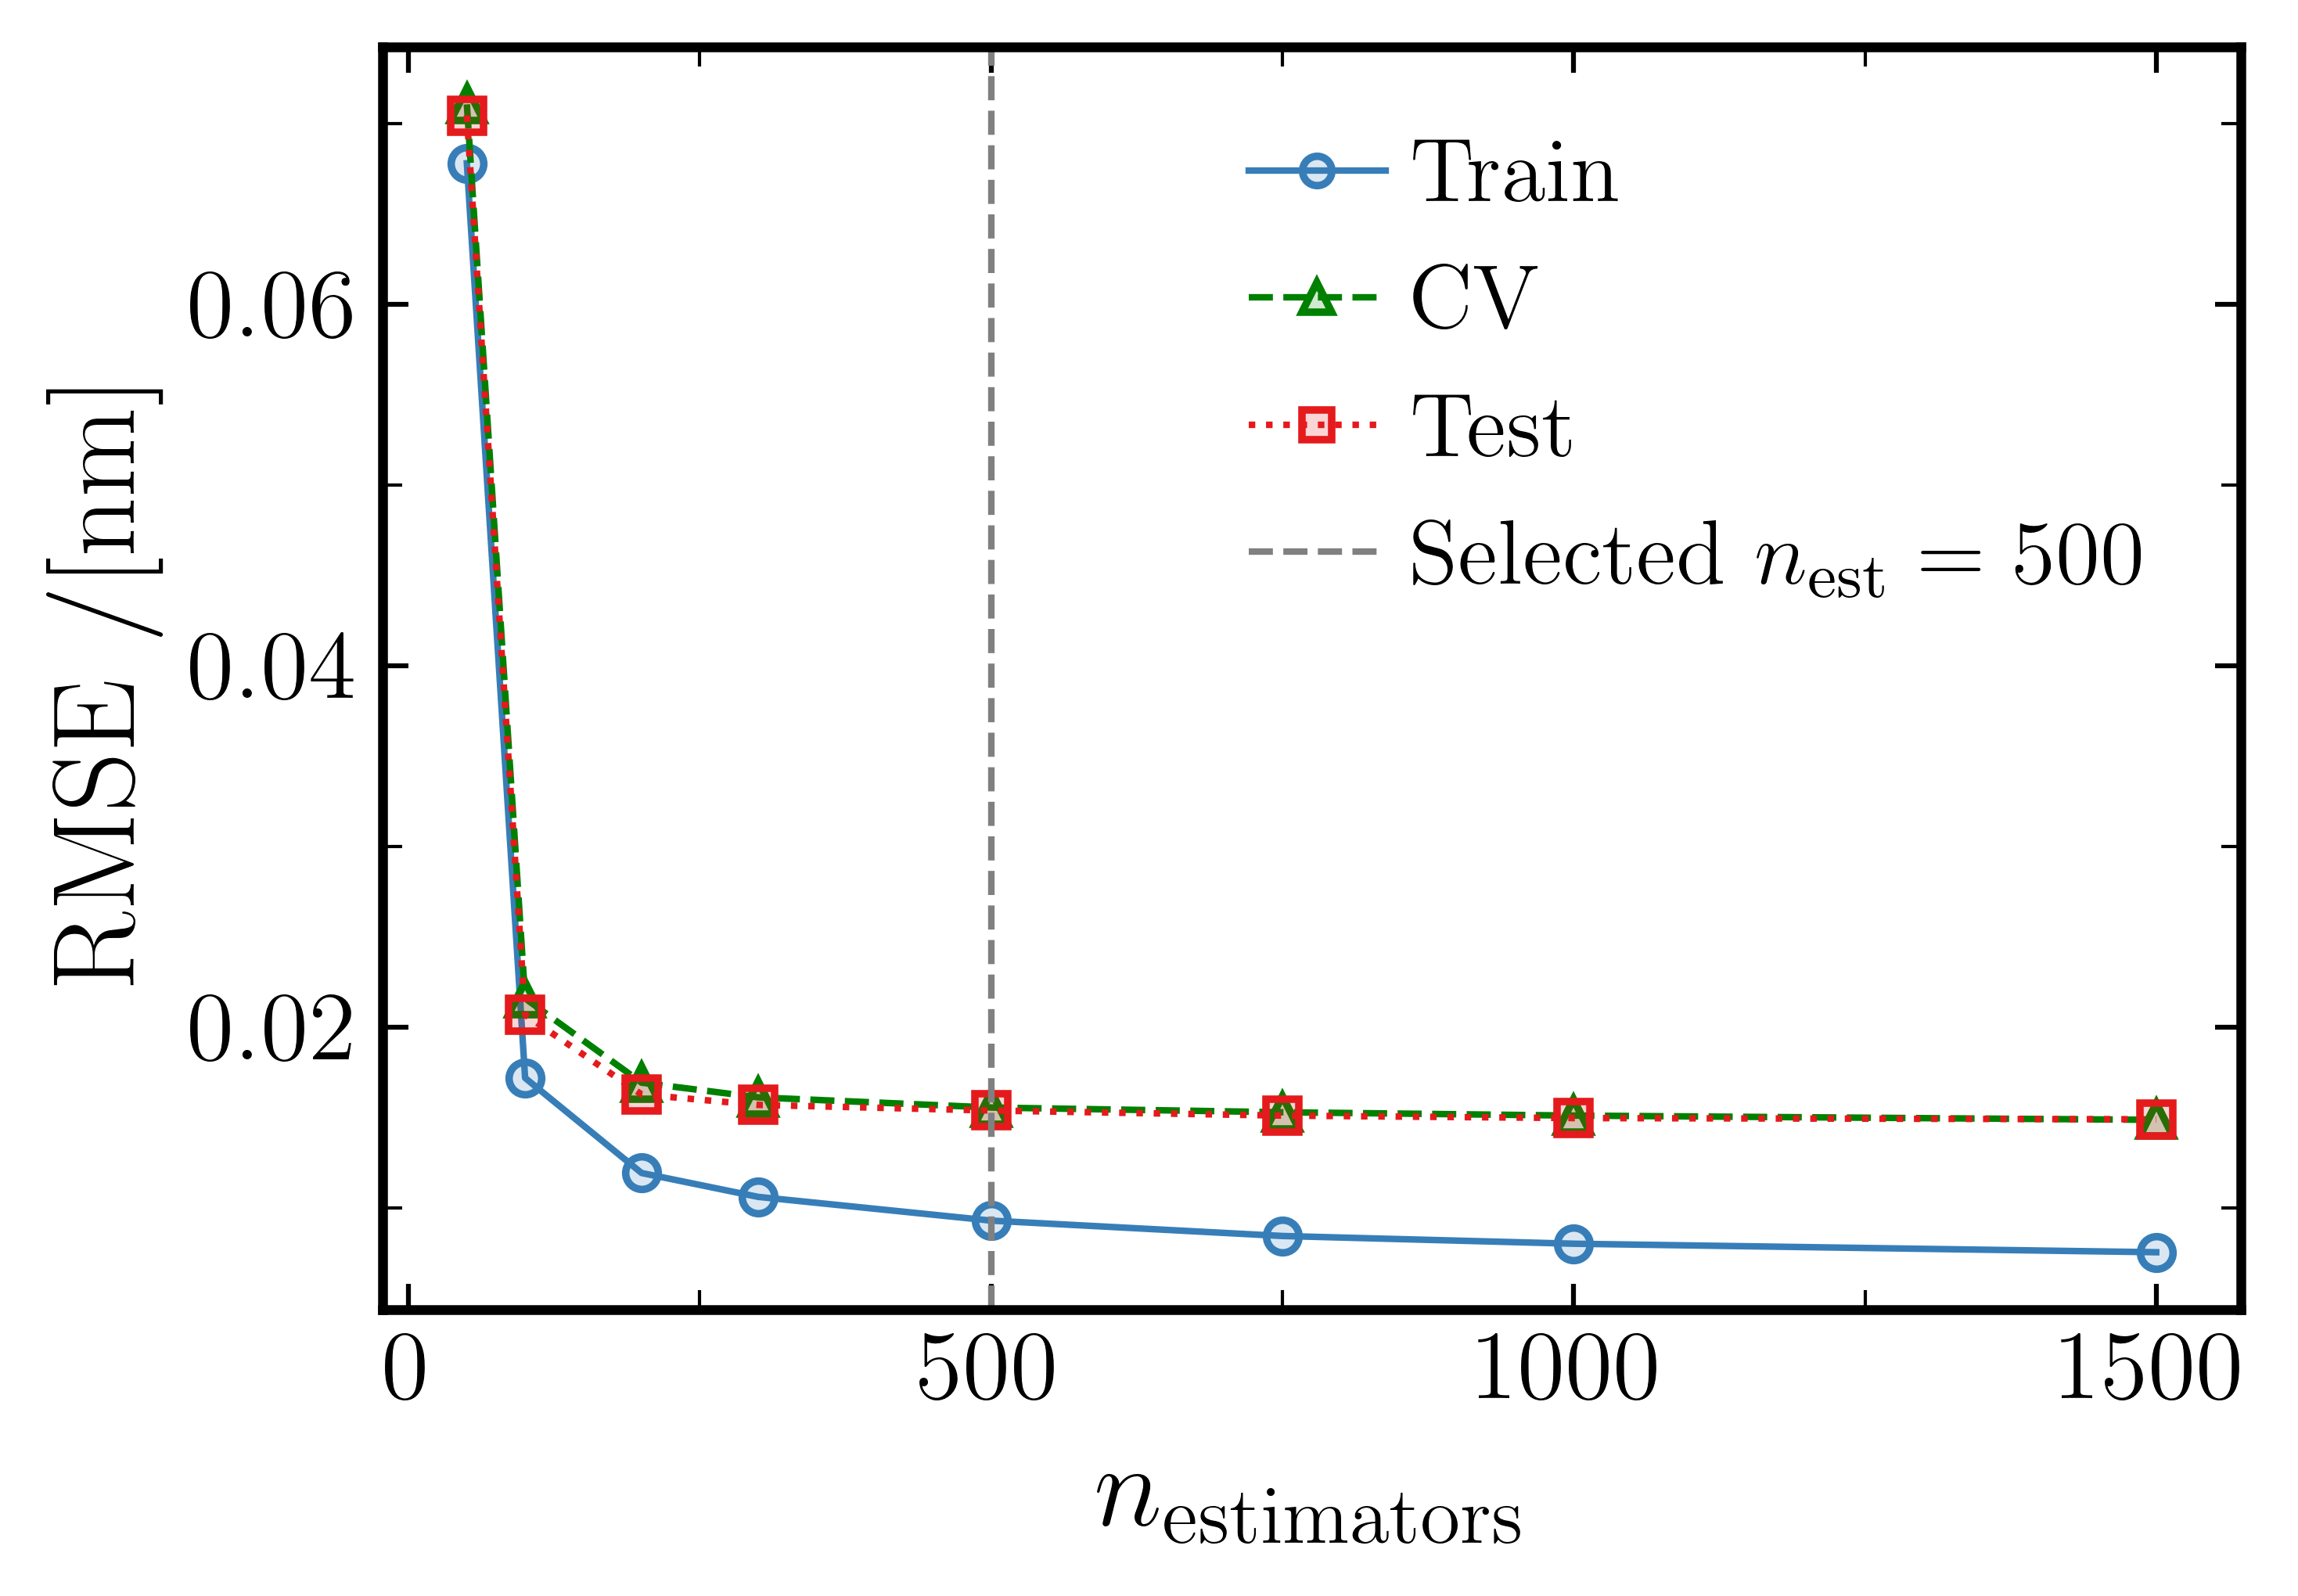

Saved: XGBoost_interfacial_thickness_n_estimators_sweep


In [ ]:
# Hyperparameter analysis: n_estimators sensitivity sweep (XGBoost)
# Hyperparameter comparison uses 5-fold CV RMSE; test RMSE is shown only as a holdout reference.
n_est_values = [50, 100, 200, 300, 500, 750, 1000, 1500]

train_rmse_n, cv_rmse_n, test_rmse_n = [], [], []
for _value in n_est_values:
    _xgb = XGBRegressor(
        n_estimators=_value,
        max_depth=xgb_model.max_depth,
        learning_rate=xgb_model.learning_rate,
        subsample=xgb_model.subsample,
        colsample_bytree=xgb_model.colsample_bytree,
        random_state=SEED,
        n_jobs=n_cpus,
    )
    _xgb.fit(X_train, y_train, verbose=False)
    train_rmse_n.append(np.sqrt(mean_squared_error(y_train, _xgb.predict(X_train))))
    test_rmse_n.append(np.sqrt(mean_squared_error(y_test,  _xgb.predict(X_test))))
    _cv = cross_validate(
        _xgb, X_train, y_train, cv=5,
        scoring={"rmse": "neg_root_mean_squared_error"},
        n_jobs=1,
    )
    cv_rmse_n.append(float(-_cv["test_rmse"].mean()))

print("n_estimators sweep complete.")
for _value, tr, cv, te in zip(n_est_values, train_rmse_n, cv_rmse_n, test_rmse_n):
    print(f"  n_est={_value:>5} | Train RMSE={tr:.4f}  CV RMSE={cv:.4f}  Test RMSE={te:.4f}")

_lfs = ps.label_fontsize + 4
_tls = ps.tick_labelsize + 5
_mfc = lambda c: (*ps.mcolors.to_rgb(c), 0.18)
_n_sel = xgb_model.n_estimators

fig, ax = ps.plot_init(w=5, h=3.5)
ax.plot(n_est_values, train_rmse_n,
        marker='o', markersize=ps.markersize + 1, lw=ps.linewidth,
        color=ps.colors[2], markerfacecolor=_mfc(ps.colors[2]),
        markeredgecolor=ps.colors[2], markeredgewidth=ps.markeredgewidth + 0.4,
        label=r'$\mathrm{Train}$')
ax.plot(n_est_values, cv_rmse_n,
        marker='^', markersize=ps.markersize + 1, lw=ps.linewidth,
        color=ps.colors[1], markerfacecolor=_mfc(ps.colors[1]),
        markeredgecolor=ps.colors[1], markeredgewidth=ps.markeredgewidth + 0.4,
        label=r'$\mathrm{CV}$')
ax.plot(n_est_values, test_rmse_n,
        marker='s', markersize=ps.markersize + 1, lw=ps.linewidth,
        color=ps.colors[0], markerfacecolor=_mfc(ps.colors[0]),
        markeredgecolor=ps.colors[0], markeredgewidth=ps.markeredgewidth + 0.4,
        label=r'$\mathrm{Test}$')
ax.axvline(_n_sel, ls='--', color='gray', lw=ps.linewidth,
           label=f'$\\mathrm{{Selected}}\\ n_\\mathrm{{est}}={_n_sel}$')
ax.set_xlabel(r"$n_{\mathrm{estimators}}$", fontsize=_lfs)
ax.set_ylabel(r"$\mathrm{RMSE}\ / [\mathrm{nm}]$", fontsize=_lfs)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:g}$"))
ax.minorticks_on()
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis='both', which='major', labelsize=_tls)
ax.tick_params(axis='both', which='minor', length=3)
# leg = ps.style_legend(ax, loc='upper right', fontsize=ps.label_fontsize)
# leg.get_frame().set_visible(False)
plt.tight_layout()
ps.save_plot(fig, f"XGBoost_{target}_n_estimators_sweep", folder=OUTPUT_FOLDER)
plt.show()
print(f"Saved: XGBoost_{target}_n_estimators_sweep")

max_depth sweep complete.
  depth=2 | Train RMSE=0.0284  CV RMSE=0.0301  Test RMSE=0.0310
  depth=3 | Train RMSE=0.0187  CV RMSE=0.0207  Test RMSE=0.0210
  depth=4 | Train RMSE=0.0140  CV RMSE=0.0174  Test RMSE=0.0170
  depth=5 | Train RMSE=0.0115  CV RMSE=0.0162  Test RMSE=0.0156
  depth=6 | Train RMSE=0.0093  CV RMSE=0.0156  Test RMSE=0.0154
  depth=7 | Train RMSE=0.0081  CV RMSE=0.0158  Test RMSE=0.0158
  depth=8 | Train RMSE=0.0074  CV RMSE=0.0162  Test RMSE=0.0163
  depth=10 | Train RMSE=0.0065  CV RMSE=0.0179  Test RMSE=0.0172


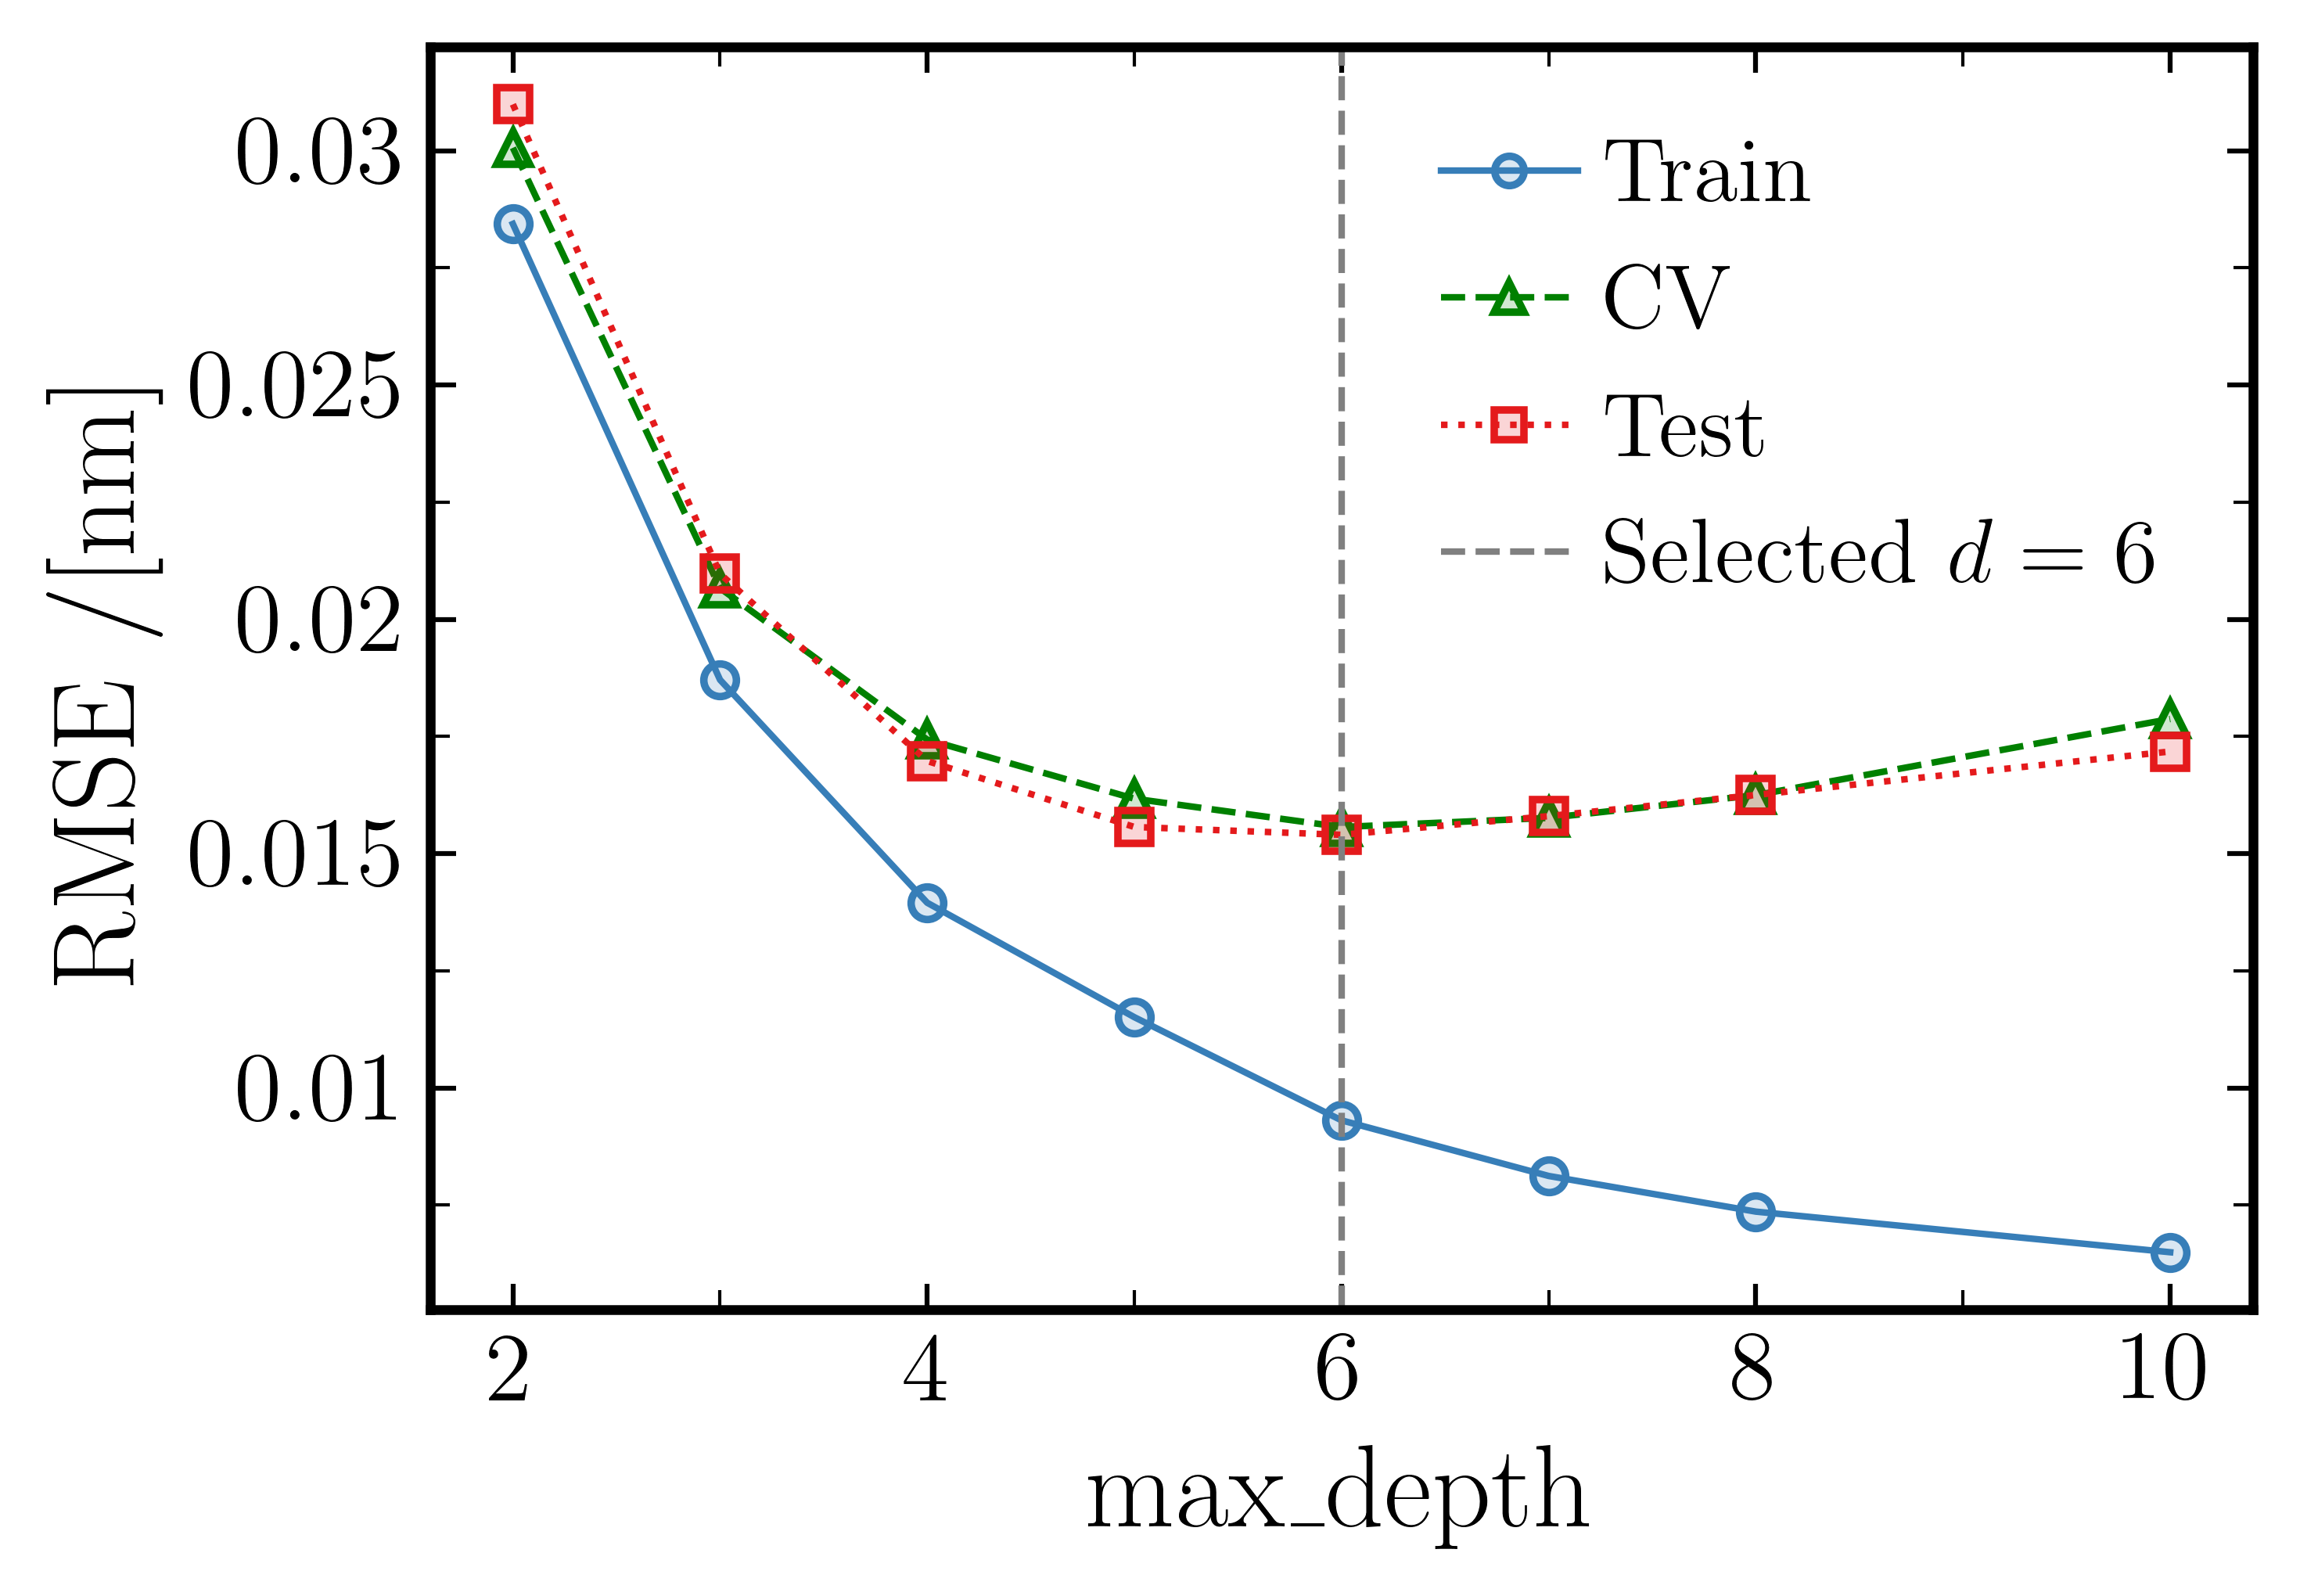

Saved: XGBoost_interfacial_thickness_max_depth_sweep


In [ ]:
# Hyperparameter analysis: max_depth sensitivity sweep (XGBoost)
# Hyperparameter comparison uses 5-fold CV RMSE; test RMSE is shown only as a holdout reference.
depth_values = [2, 3, 4, 5, 6, 7, 8, 10]

train_rmse_d, cv_rmse_d, test_rmse_d = [], [], []
for _value in depth_values:
    _xgb = XGBRegressor(
        n_estimators=xgb_model.n_estimators,
        max_depth=_value,
        learning_rate=xgb_model.learning_rate,
        subsample=xgb_model.subsample,
        colsample_bytree=xgb_model.colsample_bytree,
        random_state=SEED,
        n_jobs=n_cpus,
    )
    _xgb.fit(X_train, y_train, verbose=False)
    train_rmse_d.append(np.sqrt(mean_squared_error(y_train, _xgb.predict(X_train))))
    test_rmse_d.append(np.sqrt(mean_squared_error(y_test,  _xgb.predict(X_test))))
    _cv = cross_validate(
        _xgb, X_train, y_train, cv=5,
        scoring={"rmse": "neg_root_mean_squared_error"},
        n_jobs=1,
    )
    cv_rmse_d.append(float(-_cv["test_rmse"].mean()))

print("max_depth sweep complete.")
for _value, tr, cv, te in zip(depth_values, train_rmse_d, cv_rmse_d, test_rmse_d):
    print(f"  depth={_value} | Train RMSE={tr:.4f}  CV RMSE={cv:.4f}  Test RMSE={te:.4f}")

_lfs = ps.label_fontsize + 4
_tls = ps.tick_labelsize + 5
_mfc = lambda c: (*ps.mcolors.to_rgb(c), 0.18)
_d_sel = xgb_model.max_depth

fig, ax = ps.plot_init(w=5, h=3.5)
ax.plot(depth_values, train_rmse_d,
        marker='o', markersize=ps.markersize + 1, lw=ps.linewidth,
        color=ps.colors[2], markerfacecolor=_mfc(ps.colors[2]),
        markeredgecolor=ps.colors[2], markeredgewidth=ps.markeredgewidth + 0.4,
        label=r'$\mathrm{Train}$')
ax.plot(depth_values, cv_rmse_d,
        marker='^', markersize=ps.markersize + 1, lw=ps.linewidth,
        color=ps.colors[1], markerfacecolor=_mfc(ps.colors[1]),
        markeredgecolor=ps.colors[1], markeredgewidth=ps.markeredgewidth + 0.4,
        label=r'$\mathrm{CV}$')
ax.plot(depth_values, test_rmse_d,
        marker='s', markersize=ps.markersize + 1, lw=ps.linewidth,
        color=ps.colors[0], markerfacecolor=_mfc(ps.colors[0]),
        markeredgecolor=ps.colors[0], markeredgewidth=ps.markeredgewidth + 0.4,
        label=r'$\mathrm{Test}$')
ax.axvline(_d_sel, ls='--', color='gray', lw=ps.linewidth,
           label=f'$\\mathrm{{Selected}}\\ d={_d_sel}$')
ax.set_xlabel(r"$\mathrm{max\_depth}$", fontsize=_lfs)
ax.set_ylabel(r"$\mathrm{RMSE}\ / [\mathrm{nm}]$", fontsize=_lfs)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:g}$"))
ax.minorticks_on()
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis='both', which='major', labelsize=_tls)
ax.tick_params(axis='both', which='minor', length=3)
# leg = ps.style_legend(ax, loc='upper right', fontsize=ps.label_fontsize)
# leg.get_frame().set_visible(False)
plt.tight_layout()
ps.save_plot(fig, f"XGBoost_{target}_max_depth_sweep", folder=OUTPUT_FOLDER)
plt.show()
print(f"Saved: XGBoost_{target}_max_depth_sweep")

learning_rate sweep complete.
  lr=0.001 | Train RMSE=0.4279  CV RMSE=0.4288  Test RMSE=0.4330
  lr=0.005 | Train RMSE=0.0716  CV RMSE=0.0746  Test RMSE=0.0744
  lr=0.010 | Train RMSE=0.0176  CV RMSE=0.0221  Test RMSE=0.0210
  lr=0.050 | Train RMSE=0.0093  CV RMSE=0.0156  Test RMSE=0.0154
  lr=0.100 | Train RMSE=0.0084  CV RMSE=0.0155  Test RMSE=0.0150
  lr=0.200 | Train RMSE=0.0080  CV RMSE=0.0168  Test RMSE=0.0159
  lr=0.300 | Train RMSE=0.0079  CV RMSE=0.0186  Test RMSE=0.0161
  lr=0.500 | Train RMSE=0.0080  CV RMSE=0.0220  Test RMSE=0.0175


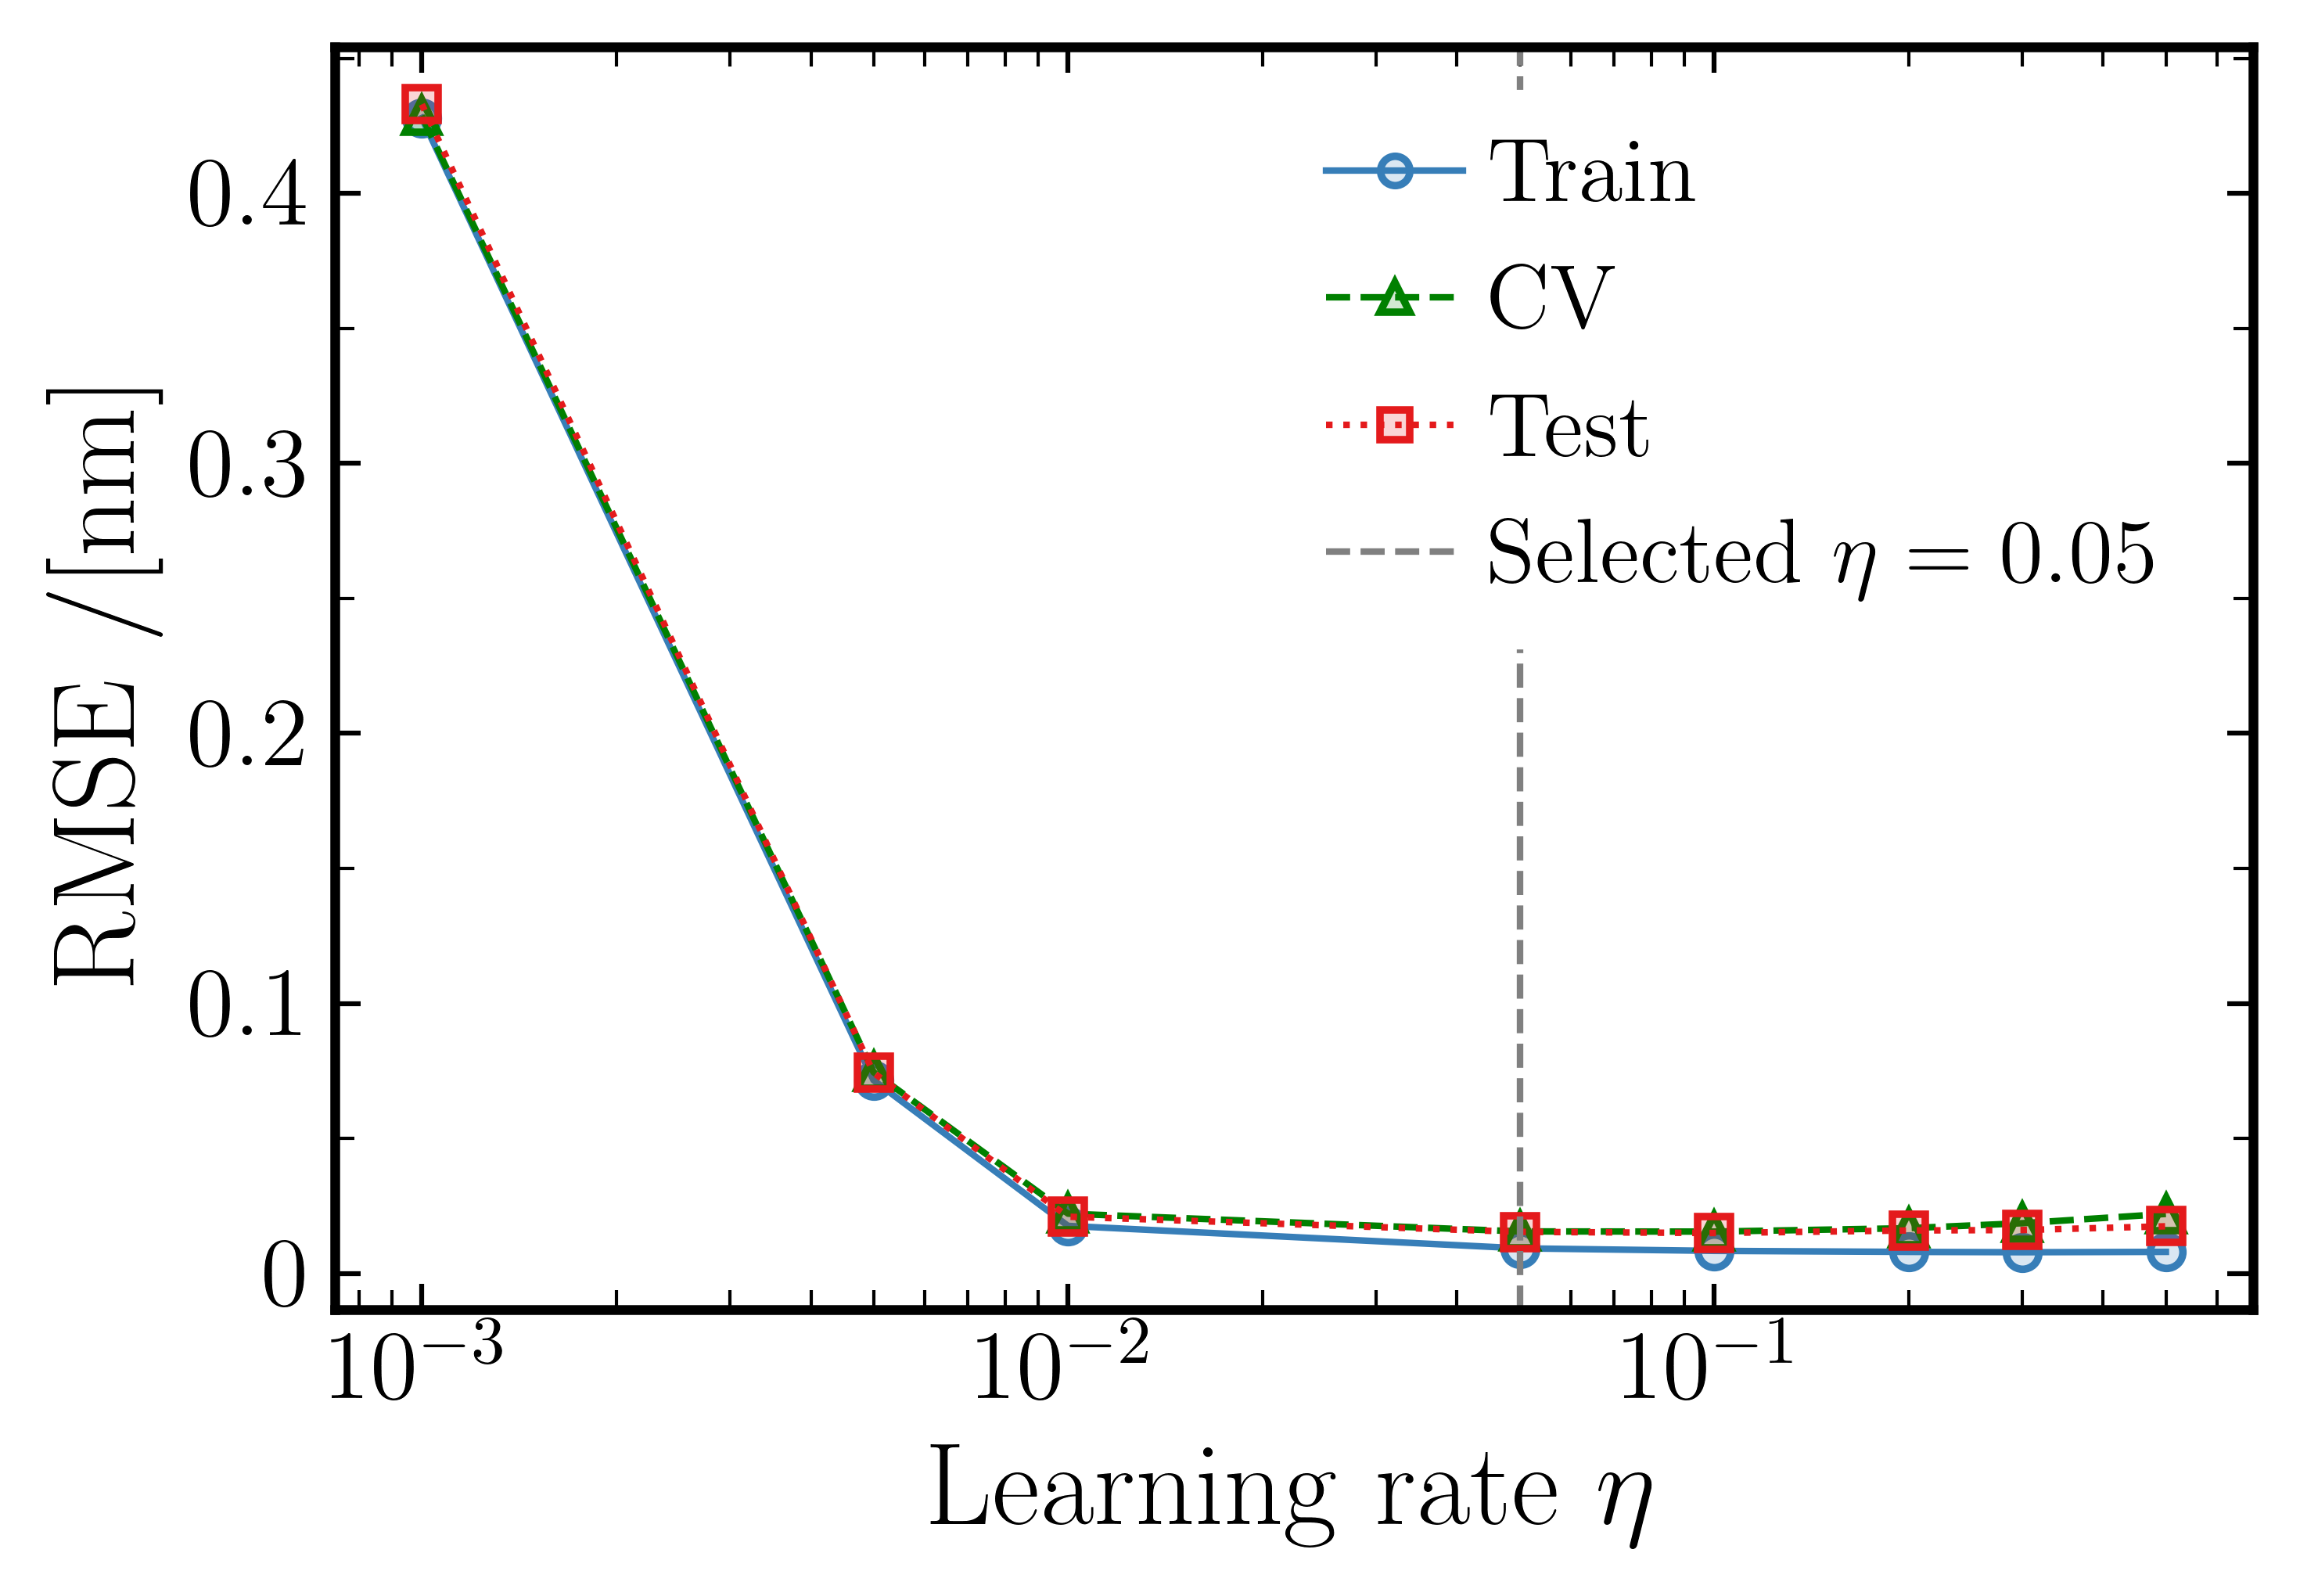

Saved: XGBoost_interfacial_thickness_learning_rate_sweep


In [ ]:
# Hyperparameter analysis: learning_rate sensitivity sweep (XGBoost)
# Hyperparameter comparison uses 5-fold CV RMSE; test RMSE is shown only as a holdout reference.
lr_values = [0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5]

train_rmse_lr, cv_rmse_lr, test_rmse_lr = [], [], []
for _value in lr_values:
    _xgb = XGBRegressor(
        n_estimators=xgb_model.n_estimators,
        max_depth=xgb_model.max_depth,
        learning_rate=_value,
        subsample=xgb_model.subsample,
        colsample_bytree=xgb_model.colsample_bytree,
        random_state=SEED,
        n_jobs=n_cpus,
    )
    _xgb.fit(X_train, y_train, verbose=False)
    train_rmse_lr.append(np.sqrt(mean_squared_error(y_train, _xgb.predict(X_train))))
    test_rmse_lr.append(np.sqrt(mean_squared_error(y_test,  _xgb.predict(X_test))))
    _cv = cross_validate(
        _xgb, X_train, y_train, cv=5,
        scoring={"rmse": "neg_root_mean_squared_error"},
        n_jobs=1,
    )
    cv_rmse_lr.append(float(-_cv["test_rmse"].mean()))

print("learning_rate sweep complete.")
for _value, tr, cv, te in zip(lr_values, train_rmse_lr, cv_rmse_lr, test_rmse_lr):
    print(f"  lr={_value:.3f} | Train RMSE={tr:.4f}  CV RMSE={cv:.4f}  Test RMSE={te:.4f}")

_lfs = ps.label_fontsize + 4
_tls = ps.tick_labelsize + 5
_mfc = lambda c: (*ps.mcolors.to_rgb(c), 0.18)
_lr_sel = xgb_model.learning_rate

fig, ax = ps.plot_init(w=5, h=3.5)
ax.semilogx(lr_values, train_rmse_lr,
        marker='o', markersize=ps.markersize + 1, lw=ps.linewidth,
        color=ps.colors[2], markerfacecolor=_mfc(ps.colors[2]),
        markeredgecolor=ps.colors[2], markeredgewidth=ps.markeredgewidth + 0.4,
        label=r'$\mathrm{Train}$')
ax.semilogx(lr_values, cv_rmse_lr,
        marker='^', markersize=ps.markersize + 1, lw=ps.linewidth,
        color=ps.colors[1], markerfacecolor=_mfc(ps.colors[1]),
        markeredgecolor=ps.colors[1], markeredgewidth=ps.markeredgewidth + 0.4,
        label=r'$\mathrm{CV}$')
ax.semilogx(lr_values, test_rmse_lr,
        marker='s', markersize=ps.markersize + 1, lw=ps.linewidth,
        color=ps.colors[0], markerfacecolor=_mfc(ps.colors[0]),
        markeredgecolor=ps.colors[0], markeredgewidth=ps.markeredgewidth + 0.4,
        label=r'$\mathrm{Test}$')
ax.axvline(_lr_sel, ls='--', color='gray', lw=ps.linewidth,
           label=f'$\\mathrm{{Selected}}\\ \\eta={_lr_sel}$')
ax.set_xlabel(r"$\mathrm{Learning}\ \mathrm{rate}\ \eta$", fontsize=_lfs)
ax.set_ylabel(r"$\mathrm{RMSE}\ / [\mathrm{nm}]$", fontsize=_lfs)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:g}$"))
ax.minorticks_on()
ax.xaxis.set_minor_locator(LogLocator(subs="auto"))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis='both', which='major', labelsize=_tls)
ax.tick_params(axis='both', which='minor', length=3)
# leg = ps.style_legend(ax, loc='upper right', fontsize=ps.label_fontsize)
# leg.get_frame().set_visible(False)
# frame = leg.get_frame()
# frame.set_visible(True)
# frame.set_facecolor("white")
# frame.set_edgecolor("white")
# frame.set_alpha(1.0)
# leg.set_zorder(10)

plt.tight_layout()
ps.save_plot(fig, f"XGBoost_{target}_learning_rate_sweep", folder=OUTPUT_FOLDER)
plt.show()
print(f"Saved: XGBoost_{target}_learning_rate_sweep")

Outlier threshold (3σ): ±0.034660
Test outliers: 73/2904 (2.51%)
Val  outliers: 51/2905  (1.76%)
Saved: XGBoost_interfacial_thickness_outliers.csv (124 rows)
  idx split  source_id  temperature   pressure   actual  predicted  residual
15098  test         77        295.0  73.850816 4.421455   4.534977 -0.113522
 3084  test         15        295.0  71.469563 3.794276   3.871110 -0.076834
 4033  test         20        285.0  52.524440 2.208410   2.244492 -0.036082
16252  test         83        280.0  59.599837 1.992027   2.042915 -0.050887
12771  test         65        290.0  59.022023 2.581392   2.497652  0.083740
 4066  test         21        205.0  97.961476 0.879564   0.917973 -0.038409
  559  test          2        285.0  68.669256 2.403973   2.487603 -0.083629
 9714  test         50        215.0  78.584072 0.905645   0.983843 -0.078198
 2113  test         10        295.0  83.216832 4.282809   4.361227 -0.078418
16232  test         83        270.0  52.285892 1.591852   1.633334 -0.04

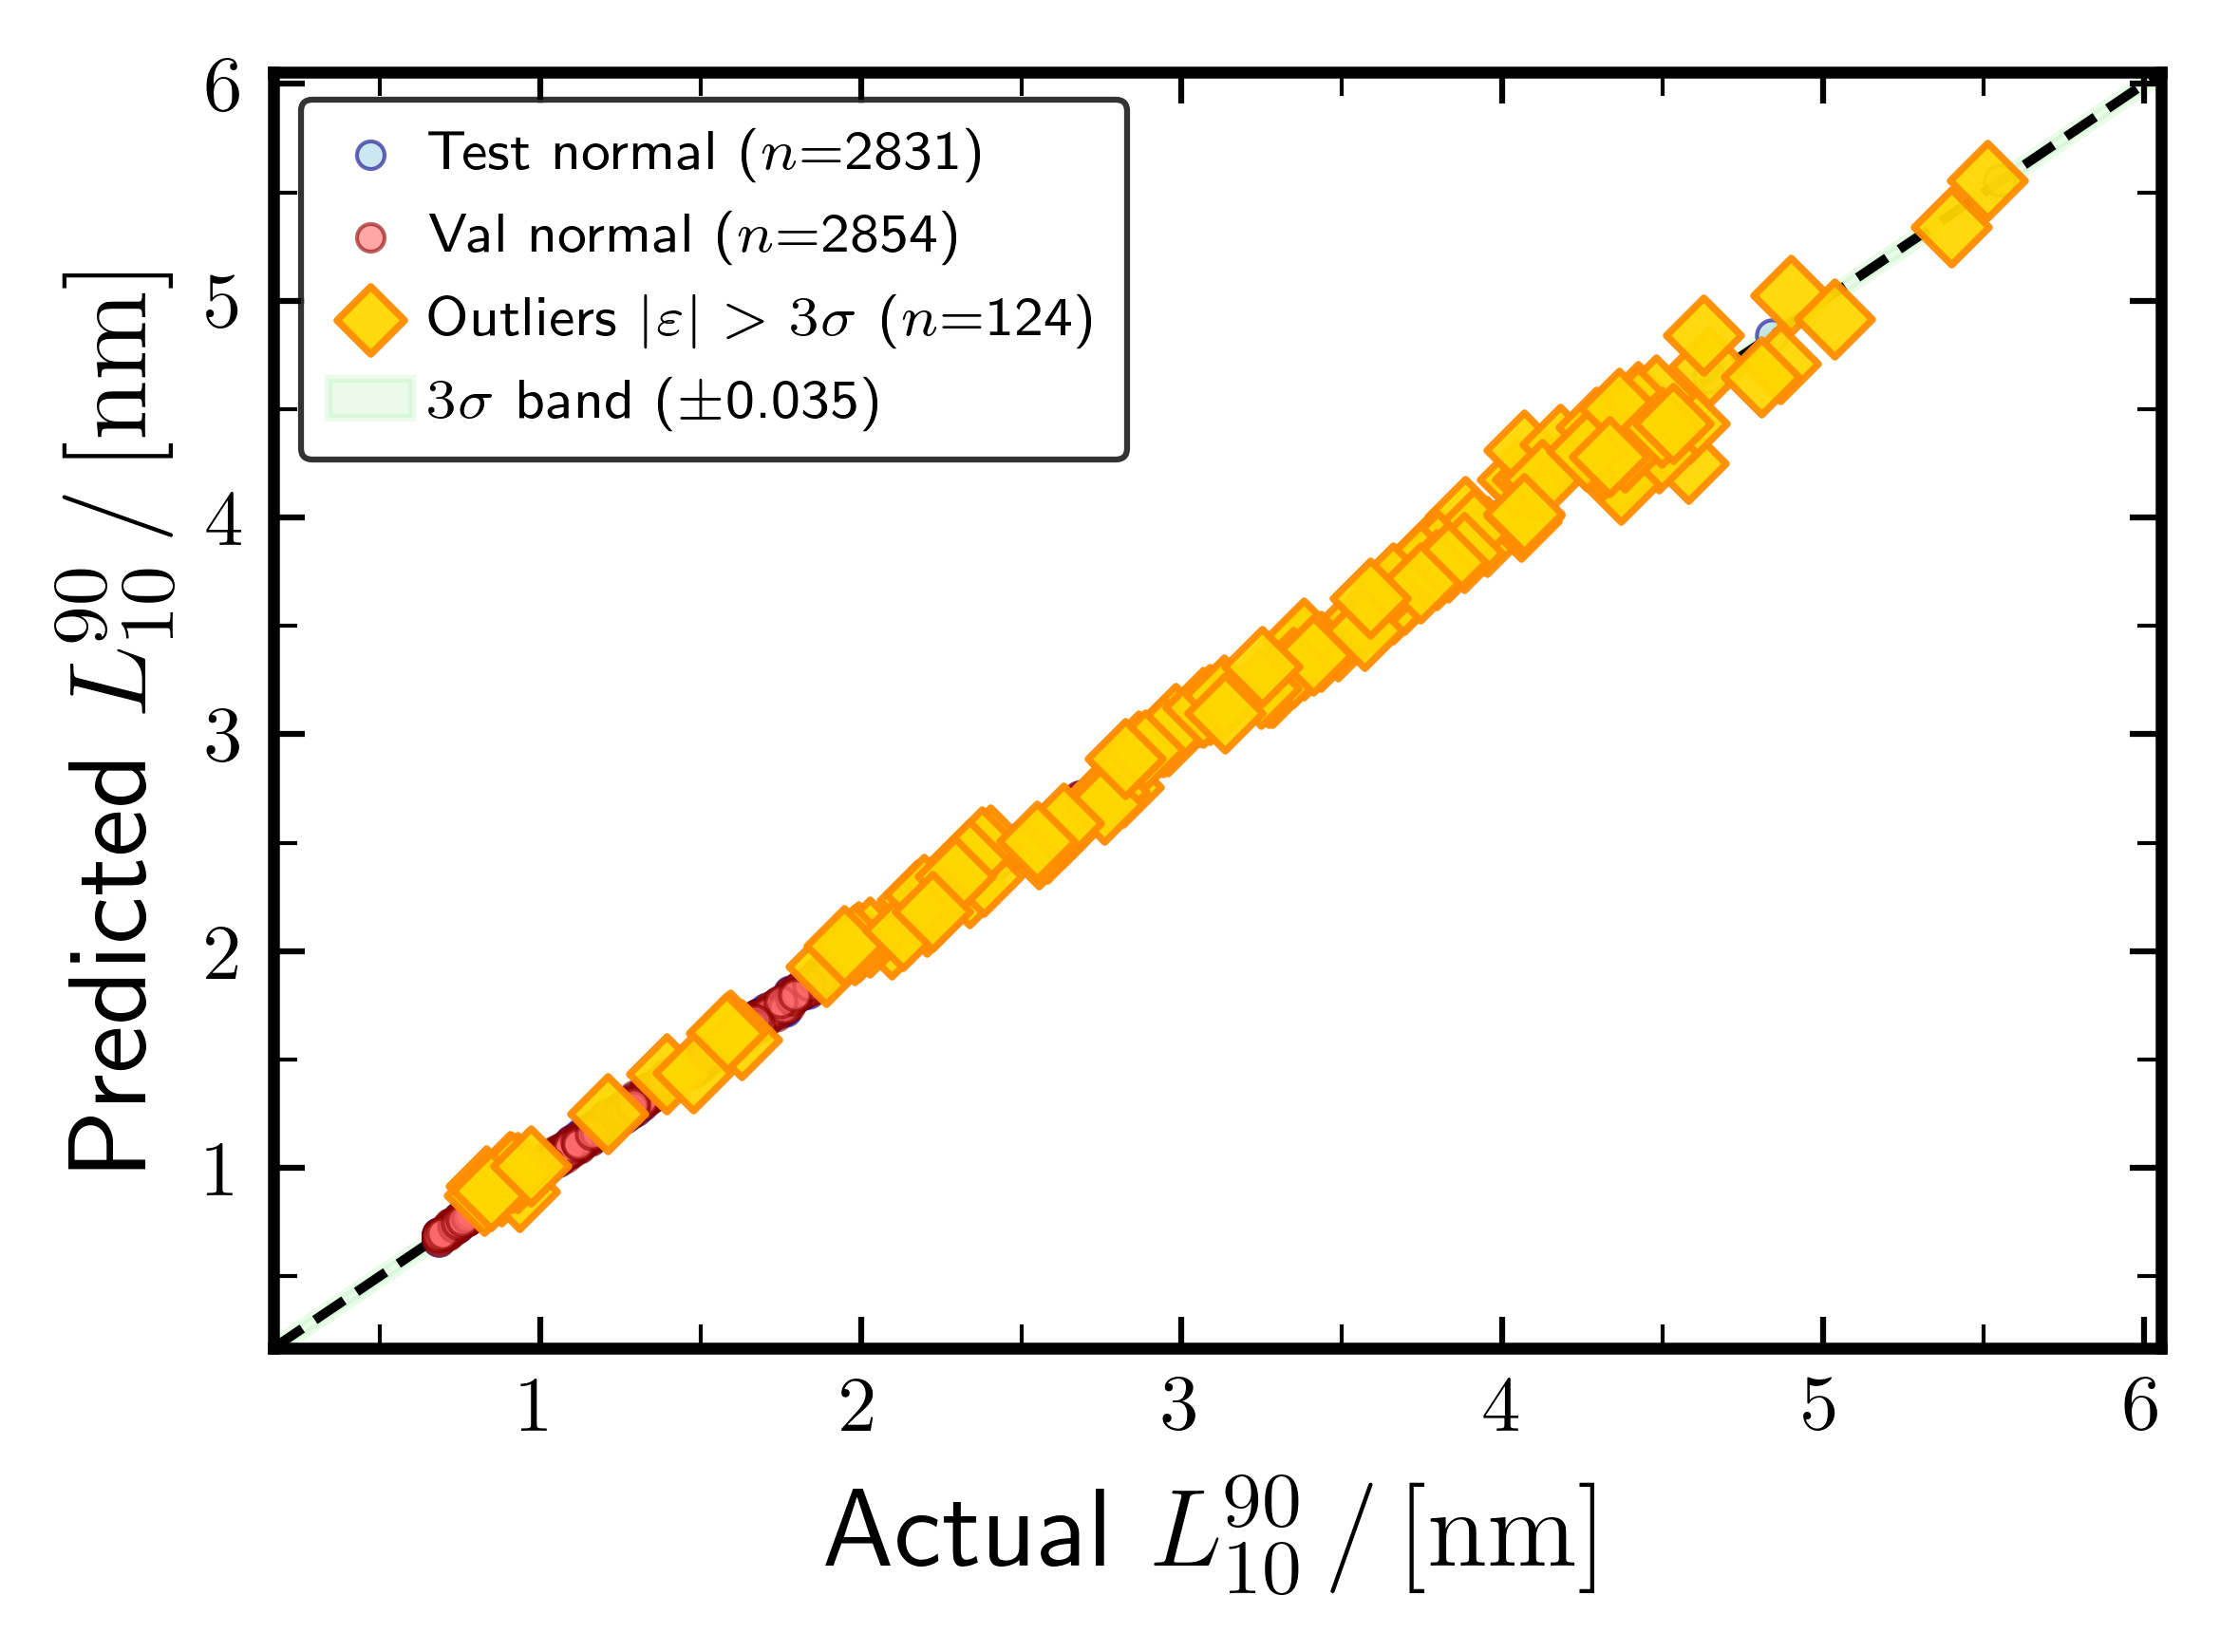

Saved: XGBoost_interfacial_thickness_outlier_parity


In [11]:
# Outlier flagging: test + val samples where |residual| > 3 * global std
all_resids_global = np.concatenate([
    np.asarray(y_train) - y_train_pred,
    np.asarray(y_test)  - y_test_pred,
    np.asarray(y_val)   - y_val_pred,
])
threshold = 3.0 * all_resids_global.std()

test_resids   = np.asarray(y_test) - y_test_pred
val_resids    = np.asarray(y_val)  - y_val_pred
test_out_mask = np.abs(test_resids) > threshold
val_out_mask  = np.abs(val_resids)  > threshold

n_test_out = int(test_out_mask.sum())
n_val_out  = int(val_out_mask.sum())
print(f"Outlier threshold (3σ): ±{threshold:.6f}")
print(f"Test outliers: {n_test_out}/{len(y_test)} ({100*n_test_out/len(y_test):.2f}%)")
print(f"Val  outliers: {n_val_out}/{len(y_val)}  ({100*n_val_out/len(y_val):.2f}%)")

outlier_df = pd.concat([
    pd.DataFrame({
        "idx":         y_test.index[test_out_mask],
        "split":       "test",
        "source_id":   df.loc[y_test.index[test_out_mask], "source_id"].values,
        "temperature": df.loc[y_test.index[test_out_mask], "temperature"].values,
        "pressure":    df.loc[y_test.index[test_out_mask], "pressure"].values,
        "actual":      np.asarray(y_test)[test_out_mask],
        "predicted":   y_test_pred[test_out_mask],
        "residual":    test_resids[test_out_mask],
    }),
    pd.DataFrame({
        "idx":         y_val.index[val_out_mask],
        "split":       "val",
        "source_id":   df.loc[y_val.index[val_out_mask], "source_id"].values,
        "temperature": df.loc[y_val.index[val_out_mask], "temperature"].values,
        "pressure":    df.loc[y_val.index[val_out_mask], "pressure"].values,
        "actual":      np.asarray(y_val)[val_out_mask],
        "predicted":   y_val_pred[val_out_mask],
        "residual":    val_resids[val_out_mask],
    }),
], ignore_index=True)
outlier_df.to_csv(os.path.join(OUTPUT_FOLDER, f"XGBoost_{target}_outliers.csv"), index=False)
print(f"Saved: XGBoost_{target}_outliers.csv ({len(outlier_df)} rows)")
print(outlier_df.to_string(index=False))

# Parity plot highlighting outliers
fig, ax = ps.plot_init()

for y_true_sp, y_pred_sp, out_mask, fc, ec, lbl in [
    (y_test, y_test_pred, test_out_mask, "lightblue", "darkblue", "Test"),
    (y_val,  y_val_pred,  val_out_mask,  "#FF6B6B",   "darkred",  "Val"),
]:
    norm = ~out_mask
    ax.scatter(
        np.asarray(y_true_sp)[norm], y_pred_sp[norm],
        alpha=0.6, s=15, facecolors=fc, edgecolors=ec,
        linewidths=0.5, zorder=2,
        label=rf"{lbl} normal ($n$={int(norm.sum())})",
    )

all_out_true = np.concatenate([np.asarray(y_test)[test_out_mask], np.asarray(y_val)[val_out_mask]])
all_out_pred = np.concatenate([y_test_pred[test_out_mask], y_val_pred[val_out_mask]])
if len(all_out_true) > 0:
    ax.scatter(
        all_out_true, all_out_pred,
        alpha=0.95, s=45, facecolors="gold", edgecolors="darkorange",
        linewidths=0.9, marker="D", zorder=4,
        label=rf"Outliers $|\varepsilon|>3\sigma$ ($n$={len(all_out_true)})",
    )

all_vals = np.concatenate([np.asarray(y_test), np.asarray(y_val), y_test_pred, y_val_pred])
lims     = [all_vals.min() - 0.5, all_vals.max() + 0.5]
x_line   = np.array(lims)
ax.fill_between(x_line, x_line - threshold, x_line + threshold,
                color="lightgreen", alpha=0.18, zorder=0,
                label=rf"$3\sigma$ band ($\pm${threshold:.3f})")
ax.plot(lims, lims, "k--", lw=1.2, zorder=1)
ax.set_xlim(lims)
ax.set_ylim(lims)

target_label_str = ps.label_map.get(target.lower(), target)
ax.set_xlabel(f"Actual {target_label_str}", fontsize=ps.label_fontsize)
ax.set_ylabel(f"Predicted {target_label_str}", fontsize=ps.label_fontsize)
ps.apply_axis_style(ax)
ax.minorticks_on()
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis='both', which='minor', length=3)
ps.style_legend(ax, loc='upper left', fontsize=ps.label_fontsize * 0.5)
plt.tight_layout()
ps.save_plot(fig, f"XGBoost_{target}_outlier_parity", folder=OUTPUT_FOLDER)
plt.show()
print(f"Saved: XGBoost_{target}_outlier_parity")

In [12]:
# XGBoost Feature Importance
xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=list(df[features].columns)
).sort_values(ascending=False)

print("\nXGBoost Feature Importance (gain):")
print(xgb_importance.to_string())


XGBoost Feature Importance (gain):
temperature           0.875142
pressure              0.082710
z_hydrogen            0.023582
z_carbon dioxide      0.005703
z_hydrogen sulfide    0.004822
z_methane             0.002972
z_argon               0.002192
z_nitrogen            0.001382
z_oxygen              0.000794
z_carbon monoxide     0.000700


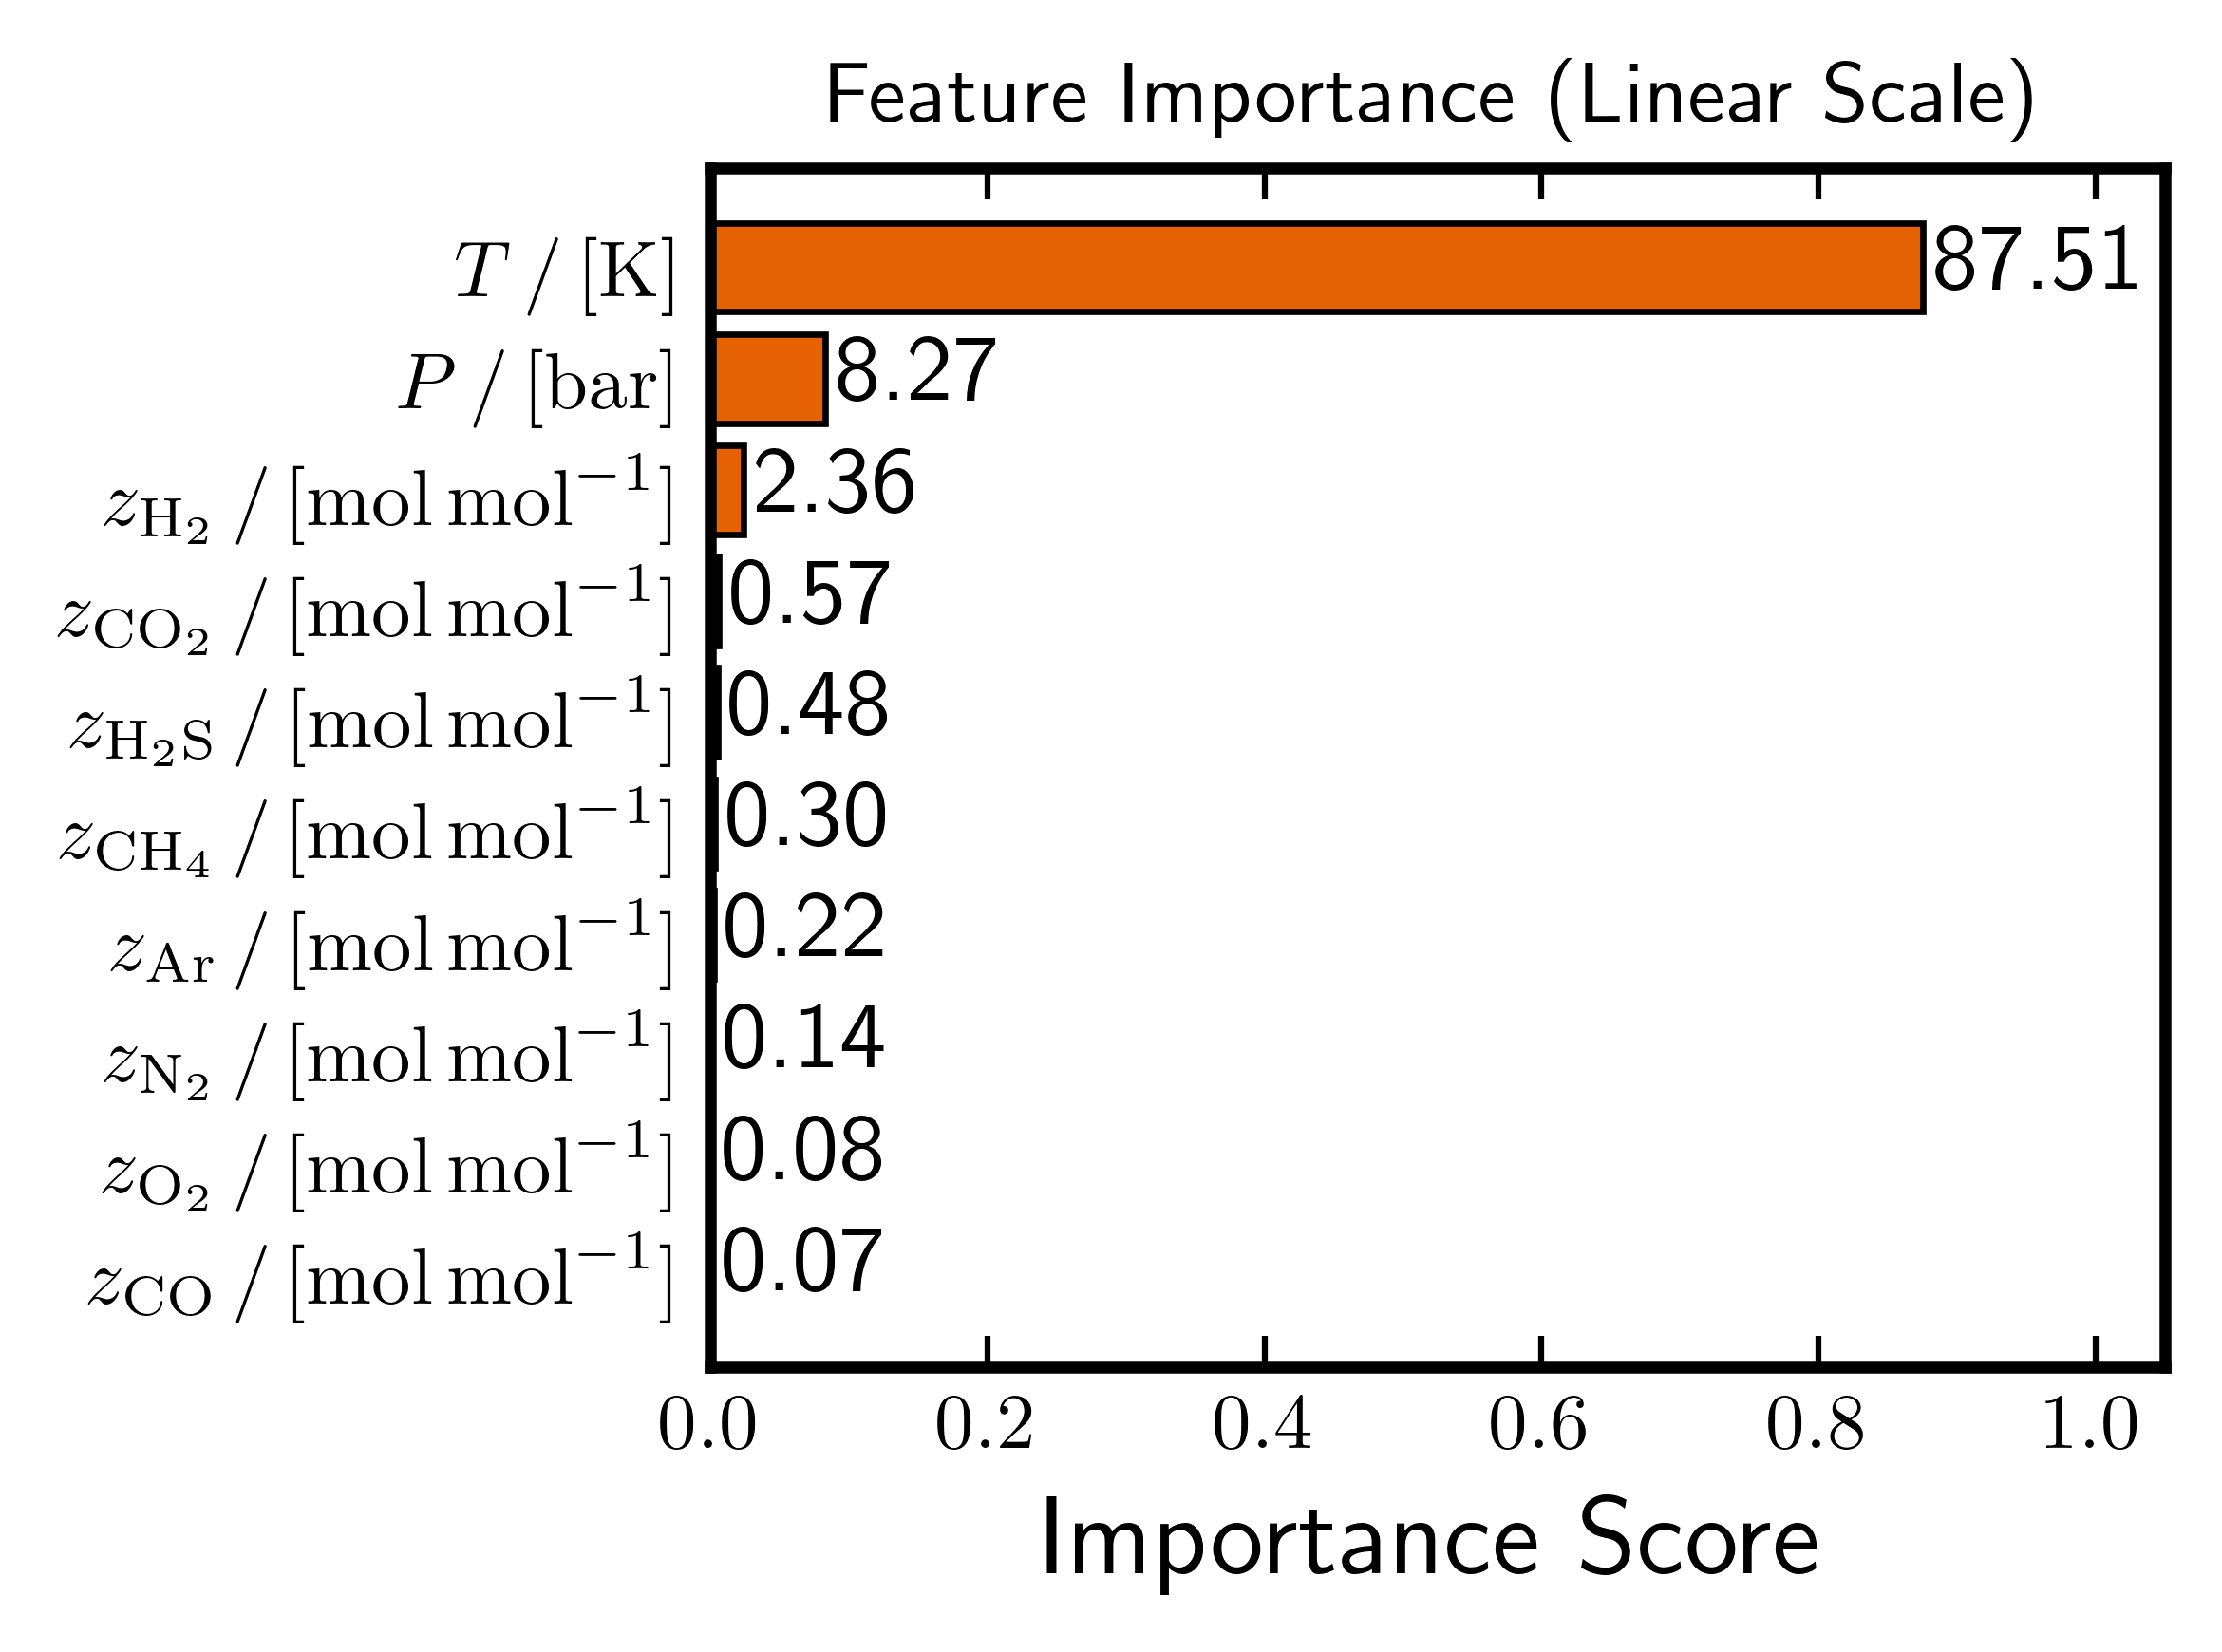

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: title={'center': 'Feature Importance (Linear Scale)'}, xlabel='Importance Score'>)

In [13]:
# Initialize MLPostprocessing
post = MLPostprocessing(
    y_true=y_test,
    y_pred=y_test_pred,
    target="interfacial_thickness",
    feature_importances=xgb_model.feature_importances_,
    feature_names=features,
    datasets={
        "train": (y_train, y_train_pred),
        "test":  (y_test,  y_test_pred),
        "val":   (y_val,   y_val_pred),
    },
)

# Plot feature importance (Linear Scale)
post.plot_feature_importance(scale="linear", color=post.colors["hist_color"], save_path="XGBoost_interfacial_thickness_feature_importance_linear", folder=OUTPUT_FOLDER)

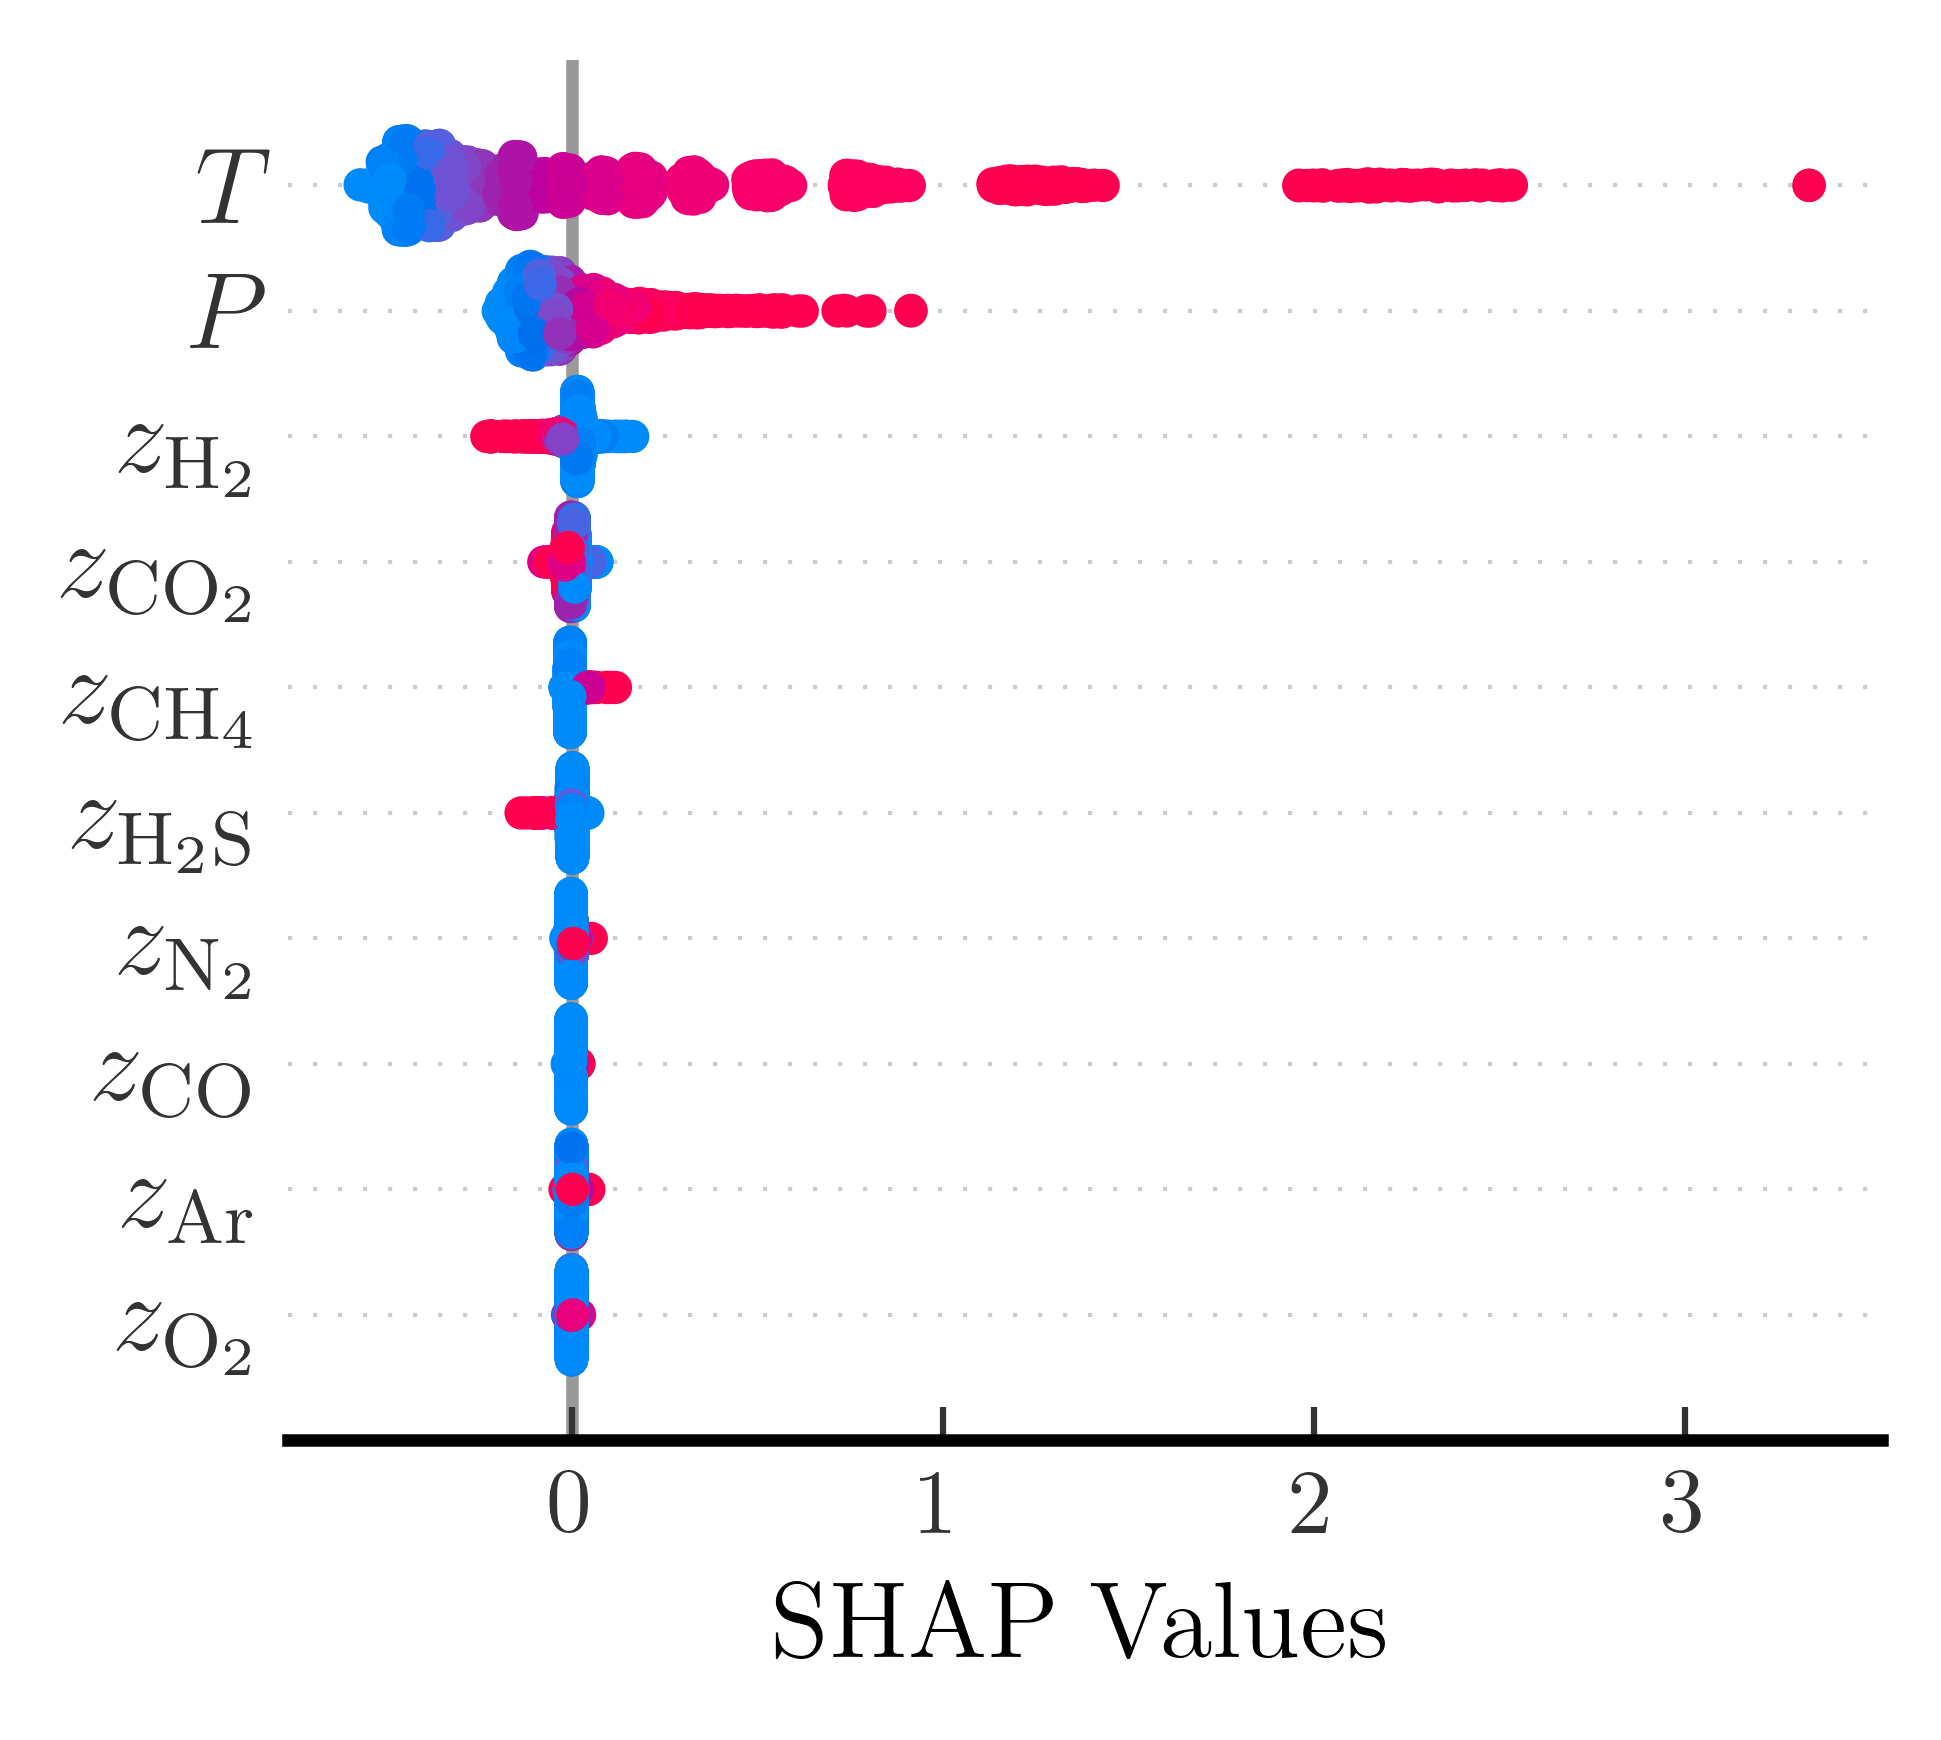

In [14]:
label_map = {
    "temperature": r"$T$",
    "pressure": r"$P$",
    "z_carbon dioxide": r"$z_{\mathrm{CO_2}}$",
    "z_hydrogen": r"$z_{\mathrm{H_2}}$",
    "z_argon": r"$z_{\mathrm{Ar}}$",
    "z_nitrogen": r"$z_{\mathrm{N_2}}$",
    "z_methane": r"$z_{\mathrm{CH_4}}$",
    "z_oxygen": r"$z_{\mathrm{O_2}}$",
    "z_carbon monoxide": r"$z_{\mathrm{CO}}$",
    "z_hydrogen sulfide": r"$z_{\mathrm{H_2S}}$",
    "interfacial_thickness": r"$L^{90}_{10}$",
}

from matplotlib.colors import Normalize

# SHAP Values — XGBoost
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

feature_labels = [label_map.get(f, f) for f in features]
shap_df = pd.DataFrame(shap_values, columns=feature_labels)

# Plot 1: Beeswarm Summary
fig, ax = ps.plot_init()
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_labels,
    show=False,
    plot_size=None)
ax = plt.gca()
ax.set_xlabel(r"$\mathrm{SHAP\;Values}$")

plt.gcf().axes[-1].remove()
sm = plt.cm.ScalarMappable(norm=Normalize(vmin=0, vmax=1), cmap=shap.plots.colors.red_blue)
sm.set_array([])

plt.tight_layout()
ps.save_plot(fig, "XGBoost_interfacial_thickness_shap_summary", folder=OUTPUT_FOLDER)
plt.show()

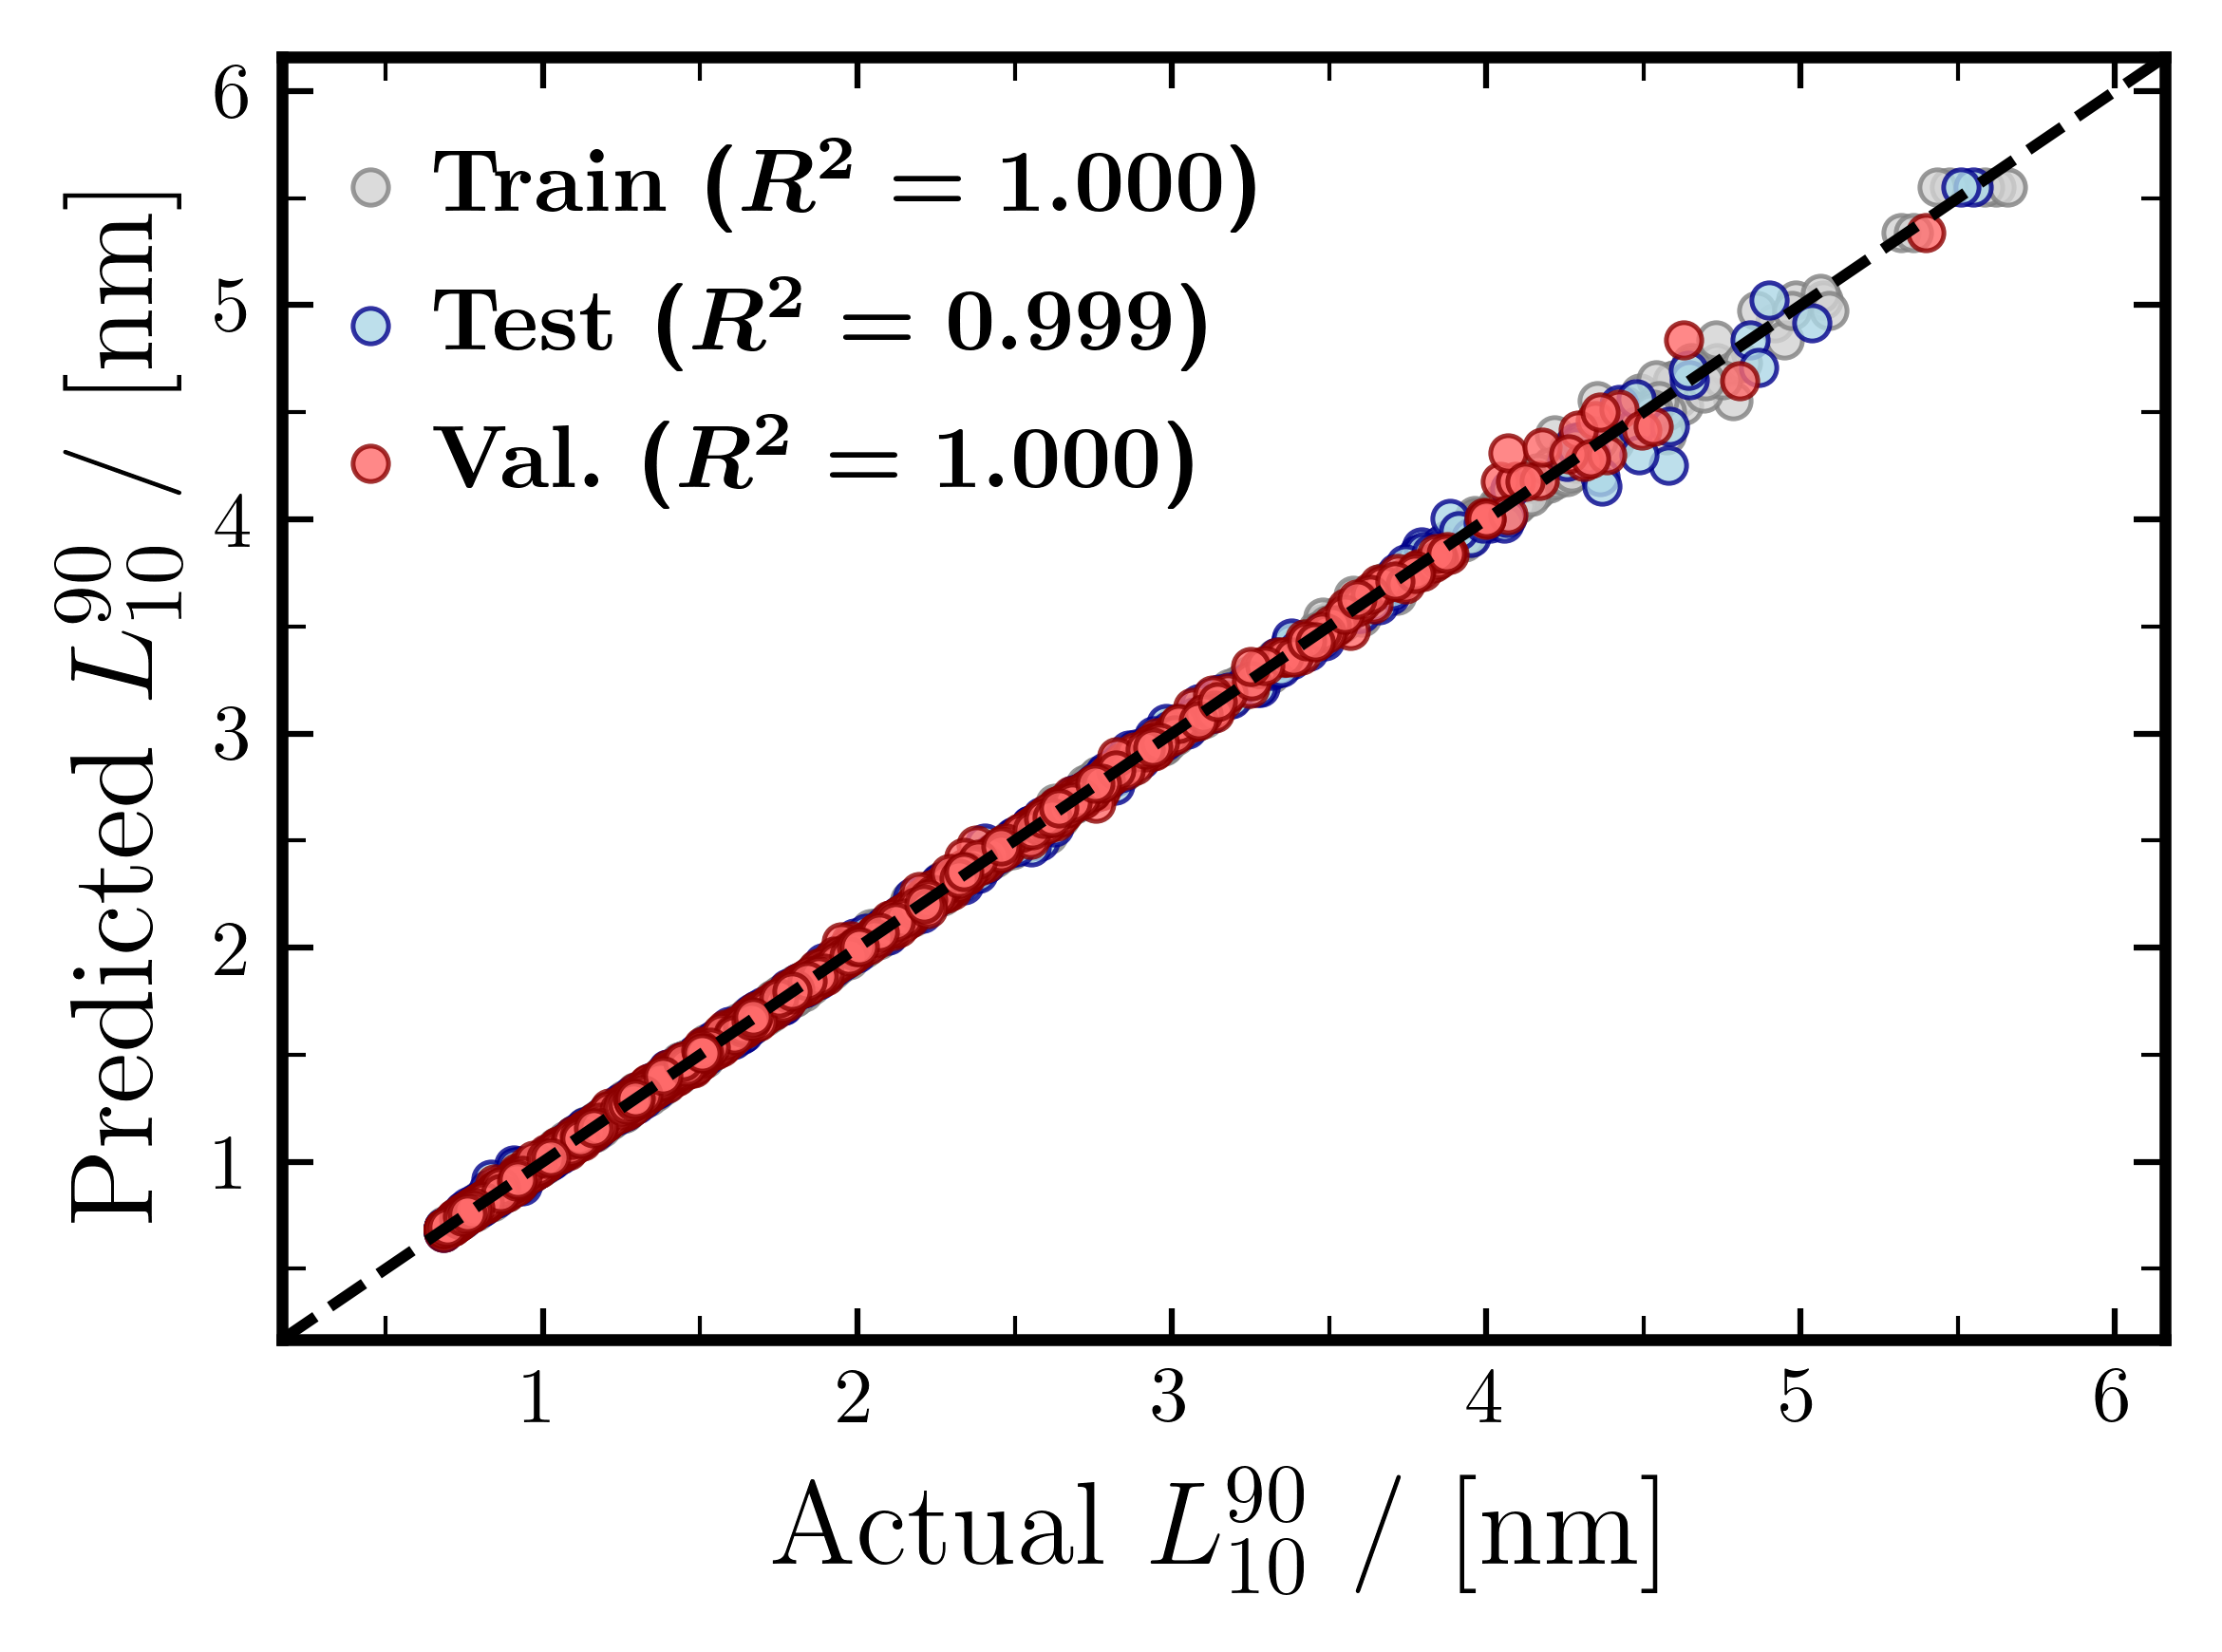

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='$\\mathrm{Actual}$ $L^{90}_{10}$ / $[\\mathrm{nm}]$', ylabel='$\\mathrm{Predicted}$ $L^{90}_{10}$ / $[\\mathrm{nm}]$'>)

In [15]:
# Parity plot
post.plot_parity(model_name="XGBoost", save_path="XGBoost_interfacial_thickness_parity_plot", folder=OUTPUT_FOLDER,
                 legend_loc=[0.005,0.62], # legend location
legend_handletextpad=0.2, # gap between marker and text
legend_handlelength=1.0, # marker-box width (smaller -> marker closer to text)
label_fontsize=15, # x/y axis label size
labelpad=4, # gap between axis and its label (points)
decimals=3, # decimal places for R^2 in legend
)

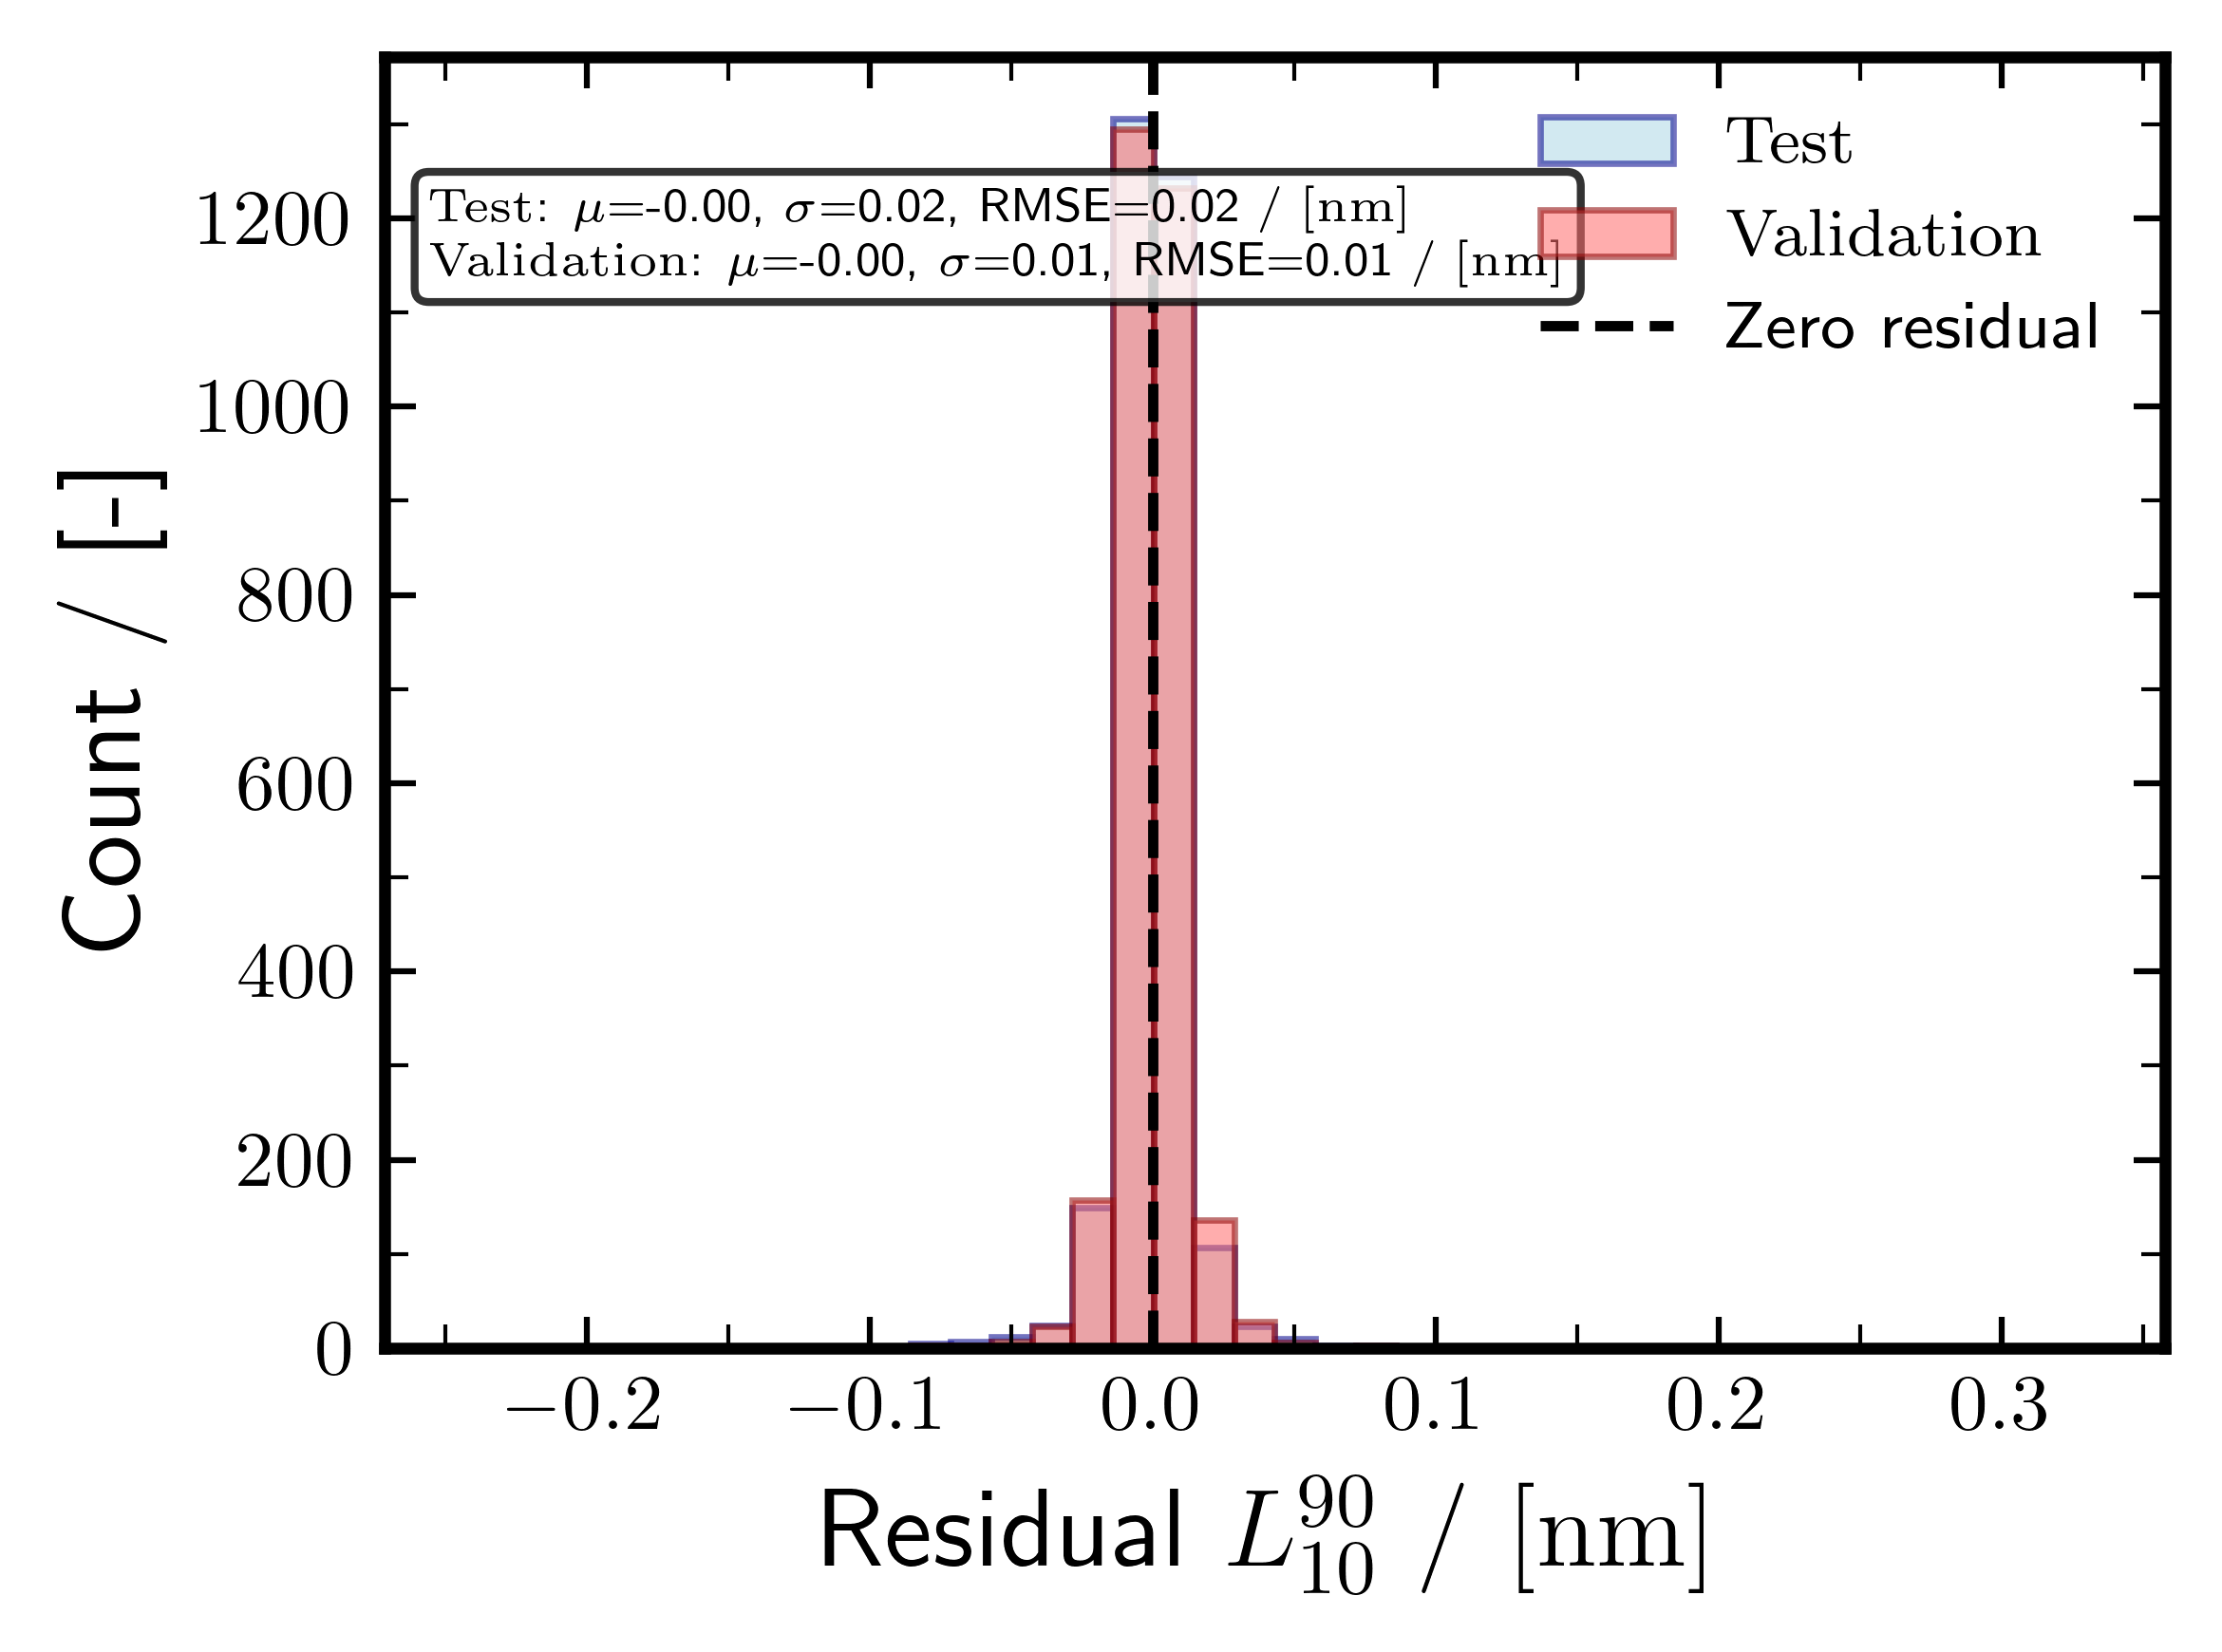

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='Residual $L^{90}_{10}$ / $[\\mathrm{nm}]$', ylabel='Count / [-]'>)

In [16]:
# Residual distribution
post.plot_residual_distribution(save_path="XGBoost_interfacial_thickness_residual_distribution", folder=OUTPUT_FOLDER)

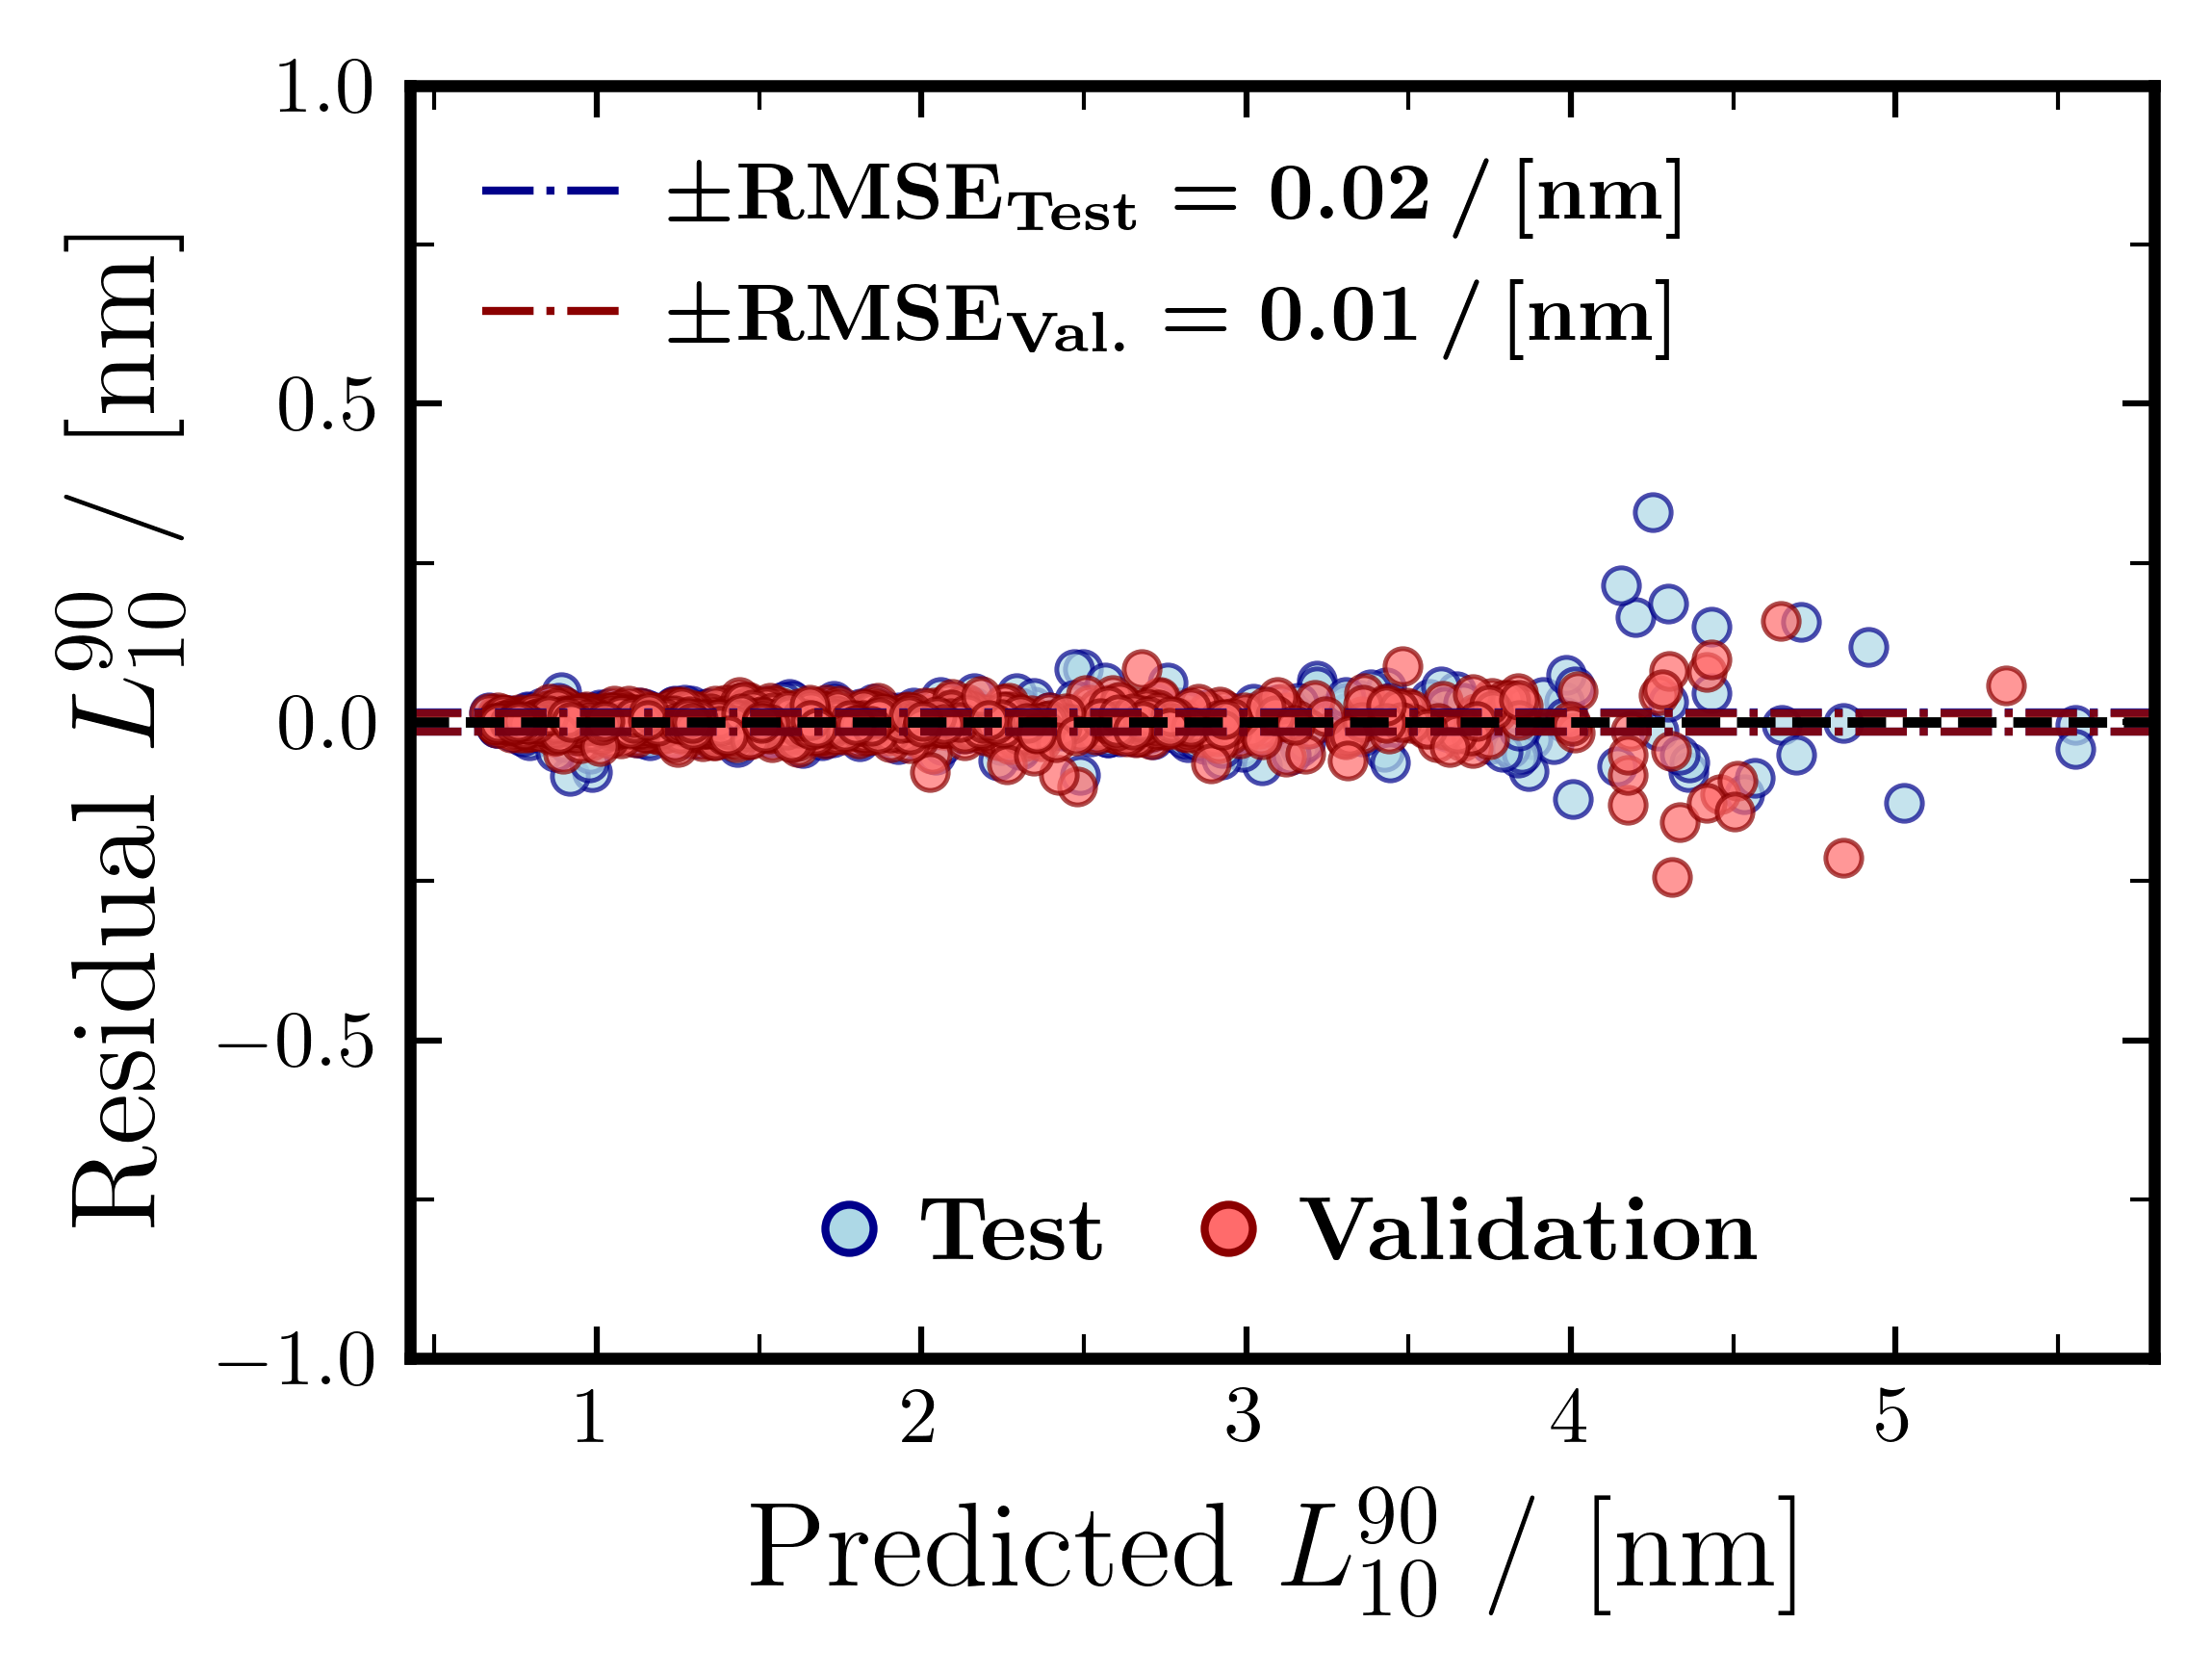

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='$\\mathrm{Predicted}$ $L^{90}_{10}$ / $[\\mathrm{nm}]$', ylabel='$\\mathrm{Residual}$ $L^{90}_{10}$ / $[\\mathrm{nm}]$'>)

In [17]:
# Residuals vs Predicted
post.plot_residual_vs_predicted(save_path="XGBoost_interfacial_thickness_residual_vs_predicted", 
                                y_range=[-1,1],
                                folder=OUTPUT_FOLDER,
                                legend_loc="lower center", # Test/Validation marker-legend location
legend_handletextpad=0.3, # gap between marker and text
legend_handlelength=1.0, # marker-box width (smaller -> marker closer to text)
label_fontsize=15, # x/y axis label size
labelpad=4, # gap between axis and its label (points)
decimals=2, # decimal places for RMSE in legend)
)

In [18]:
post.print_summary()

# Collect and save all metrics
metrics["cv_r2_scores"]    = cv_r2_scores.tolist()
metrics["cv_r2_mean"]      = float(cv_r2_scores.mean())
metrics["cv_r2_std"]       = float(cv_r2_scores.std())
metrics["cv_rmse_scores"]  = cv_rmse_scores.tolist()
metrics["cv_rmse_mean"]    = float(cv_rmse_scores.mean())
metrics["cv_rmse_std"]     = float(cv_rmse_scores.std())
metrics["cv_mae_scores"]   = cv_mae_scores.tolist()
metrics["cv_mae_mean"]     = float(cv_mae_scores.mean())
metrics["cv_mae_std"]      = float(cv_mae_scores.std())
metrics["cv_mape_scores"]  = (cv_mape_scores * 100).tolist()
metrics["cv_mape_mean"]    = float(cv_mape_scores.mean() * 100)
metrics["cv_mape_std"]     = float(cv_mape_scores.std() * 100)
metrics["n_est_sweep_values"]     = n_est_values
metrics["n_est_sweep_test_rmse"]  = test_rmse_n
metrics["n_est_sweep_cv_rmse"]    = cv_rmse_n
metrics["depth_sweep_values"]     = depth_values
metrics["depth_sweep_test_rmse"]  = test_rmse_d
metrics["depth_sweep_cv_rmse"]    = cv_rmse_d
metrics["lr_sweep_values"]        = lr_values
metrics["lr_sweep_test_rmse"]     = test_rmse_lr
metrics["lr_sweep_cv_rmse"]       = cv_rmse_lr
metrics["model"]           = "XGBoost"
metrics["n_estimators"]    = xgb_model.n_estimators
metrics["max_depth"]       = xgb_model.max_depth
metrics["learning_rate"]   = xgb_model.learning_rate
metrics["subsample"]       = xgb_model.subsample
metrics["colsample_bytree"]= xgb_model.colsample_bytree
metrics["features"]        = features
metrics["target"]          = target
metrics["seed"]            = SEED

os.makedirs(OUTPUT_FOLDER, exist_ok=True)
metrics_path = os.path.join(OUTPUT_FOLDER, f"XGBoost_{target}_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2, default=str)

print(f"\nMetrics saved to: {metrics_path}")

MODEL PERFORMANCE SUMMARY - INTERFACIAL_THICKNESS
Samples:        2904
R² Score:       0.999477
RMSE:           0.015762
MAE:            0.007852
Mean Residual:  -0.000326
Std Residual:   0.015758

FEATURE IMPORTANCES:
------------------------------------------------------------
  temperature               |  87.51% | ███████████████████████████████████████████
  pressure                  |   8.27% | ████
  z_hydrogen                |   2.36% | █
  z_carbon dioxide          |   0.57% | 
  z_hydrogen sulfide        |   0.48% | 
  z_methane                 |   0.30% | 
  z_argon                   |   0.22% | 
  z_nitrogen                |   0.14% | 
  z_oxygen                  |   0.08% | 
  z_carbon monoxide         |   0.07% | 

Metrics saved to: XGBoost_THICKNESS_OUTPUTS/XGBoost_interfacial_thickness_metrics.json


In [19]:
notebook_end = time.perf_counter()
elapsed_minutes = (notebook_end - notebook_start) / 60
print(f"Total notebook runtime: {elapsed_minutes:.2f} minutes")

Total notebook runtime: 1.77 minutes
